<h1 align="center">Atividade 1 — Estatística e Probabilidade com Python</h1>
<h2 align="center">Z-score e Distribuição Binomial, Distribuição com Amostra (<i>Sample Distribution</i>), Distribuição a partir da Amostragem (<i>Sampling Distribution</i>) e Teorema do Limite Central (TLC)</h2>

| Campo | Informação |
|---|---|
| **Aluno(a)** | **joão lucas carvalho moura** |
| **Disciplina** | *(IA)* |
| **Professor(a)** | *(claudomiro )* |
| **Turma / Semestre** | *(2)* |
| **Data** | *(03/10/26)* |

| **Vídeo de apresentação** | *(https://drive.google.com/file/d/1liblV_w5X4_ok4Voe-pa-oD3sEQ1zD8n/view?usp=sharing)* |

## Introdução geral

> **Verificação antes da entrega:** este notebook contém escolhas experimentais onde o PDF não fornece os parâmetros completos dos slides da aula. Execute todas as células no Colab com acesso ao dataset real e confira os resultados. As figuras dos enunciados já foram colocadas antes de cada parte, usando o próprio PDF da atividade.


Esta atividade percorre cinco ideias centrais da estatística, sempre com simulação em Python:

* **Parte A — Histogramas:** como a distribuição de uma característica muda de classe para classe em um dataset real (*Dry Bean Dataset*) e como o número de *bins* altera o que enxergamos. Isso conecta com a classificação por Machine Learning.
* **Parte B — Z-score:** como transformar uma variável qualquer em uma escala padrão (média 0, desvio 1) para calcular probabilidades com a distribuição normal.
* **Parte C — Distribuição Binomial:** quantos sucessos esperar em um número fixo de tentativas independentes, calculado pela equação e por simulação.
* **Parte D — *Sample distribution* e *Sampling distribution*:** diferença entre a distribuição dos valores dentro de **uma** amostra e a distribuição de uma **estatística** (a média) calculada em **muitas** amostras.
* **Parte E — Teorema do Limite Central (TLC):** mesmo partindo de uma distribuição assimétrica (Gamma), a distribuição das médias amostrais se aproxima da normal quando o tamanho da amostra cresce.

**Aviso sobre os dados:** na Parte A os dados são **reais** (UCI Machine Learning Repository). Nas Partes B, C, D e E **todos os dados são artificiais (simulados)**, gerados com sementes aleatórias fixas para que os resultados sejam reproduzíveis.

<a id="indice"></a>
## Índice

0. [Como executar este notebook e bibliotecas utilizadas](#config)
1. [Parte A — Histogramas e o Dry Bean Dataset](#parte-a)
   * [A.1 Contexto do dataset](#a1) · [A.2 Escolha das features](#a2) · [A.3 Histogramas com 10 bins](#a3) · [A.4 Histogramas com 30 bins](#a4) · [A.5 Análise e conclusão](#a5)
2. [Parte B — Z-score e tema de trabalho](#parte-b)
   * [B.1 Dados artificiais](#b1) · [B.2 Histograma e distribuição](#b2) · [B.3 Escala original](#b3) · [B.4 Padronização com Z-score](#b4) · [B.5 Função e tabela](#b5) · [B.6 Análise e conclusão](#b6)
3. [Parte C — Distribuição Binomial](#parte-c)
   * [C.1 Experimento](#c1) · [C.2 Simulação](#c2) · [C.3 Cálculo pela equação](#c3) · [C.4 Caso s = 0,80](#c4) · [C.5 Análise e conclusão](#c5)
4. [Parte D — *Sample distribution* e *Sampling distribution*](#parte-d)
   * [D.1 População](#d1) · [D.2 Uma amostra](#d2) · [D.3 Sample distribution](#d3) · [D.4 Sampling distribution](#d4) · [D.5 Probabilidades](#d5) · [D.6 Análise e conclusão](#d6)
5. [Parte E — Teorema do Limite Central com a Gamma](#parte-e)
   * [E.1 Distribuição Gamma](#e1) · [E.2 Quatro tamanhos de amostra](#e2) · [E.3 Comparação visual](#e3) · [E.4 Análise e conclusão](#e4)
6. [Limitações, hipóteses assumidas e checklist da entrega](#final)

A célula abaixo instala o `ucimlrepo` (não vem instalado por padrão no Colab). Ele é usado somente na Parte A.

In [2]:
# instala o pacote do UCI, só precisa uma vez por sessão
%pip install -q ucimlrepo

A célula abaixo importa as bibliotecas e define configurações visuais dos gráficos.

In [1]:
import math                      # funções matemáticas básicas (ex.: math.comb para combinações)
import numpy as np                # cálculos numéricos e geração de números aleatórios
import pandas as pd               # tabelas (DataFrame)
import matplotlib.pyplot as plt   # gráficos e histogramas
from scipy import stats           # distribuições de probabilidade e testes estatísticos

# algumas configurações dos gráficos
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
pd.set_option("display.precision", 4)
pd.set_option("display.width", 160)

print("Bibliotecas carregadas com sucesso.")

Bibliotecas carregadas com sucesso.


<a id="parte-a"></a>
# Parte A — Histogramas e o Dry Bean Dataset

### Figura do enunciado — Parte A

<p><b>Slide/página 10 do PDF:</b></p>
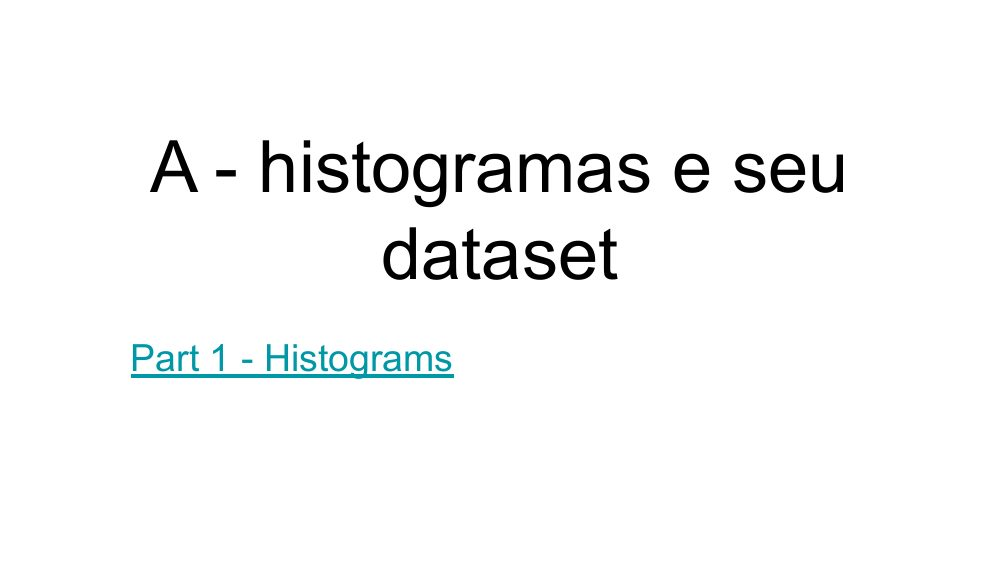

<p><b>Slide/página 11 do PDF:</b></p>
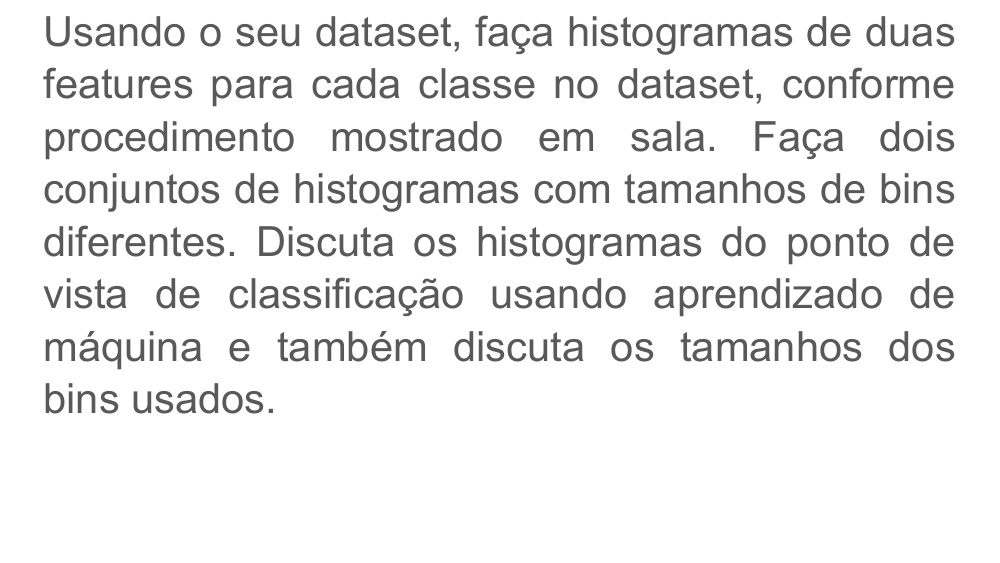

<p><b>Slide/página 12 do PDF:</b></p>
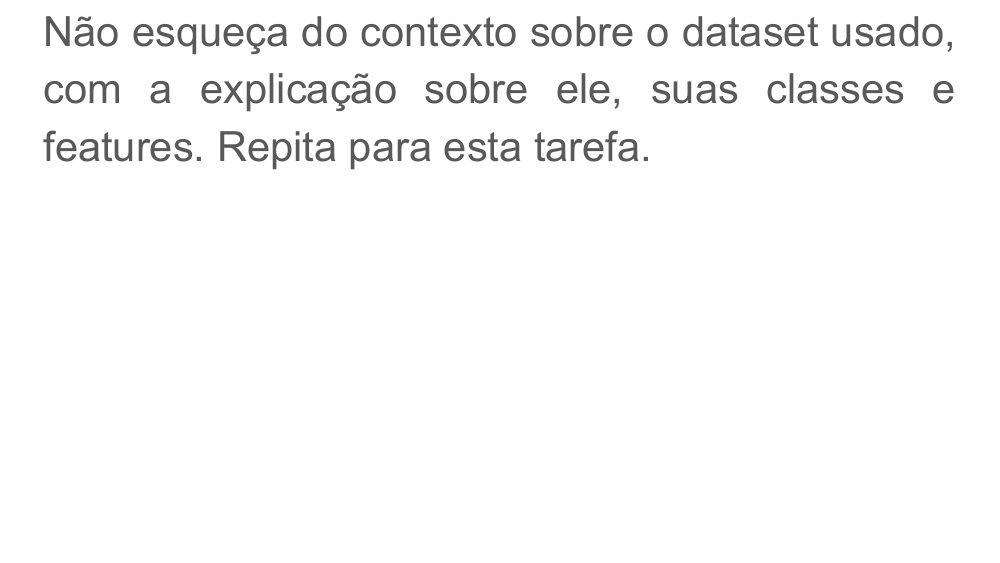



**Enunciado (resumo do PDF):** usando o seu dataset, fazer histogramas de **duas features para cada classe**, conforme procedimento mostrado em sala; fazer **dois conjuntos de histogramas com tamanhos de bins diferentes**; discutir os histogramas do ponto de vista de **classificação com aprendizado de máquina** e discutir os **tamanhos dos bins**; apresentar o contexto do dataset, suas classes e features.

<a id="a1"></a>
## A.1 — Contexto do dataset

**O que é.** O *Dry Bean Dataset* (UCI, ID 602) reúne medidas obtidas de **imagens de grãos de feijão seco** fotografados com câmera de alta resolução. Segundo a documentação do próprio dataset, as imagens passaram por segmentação e extração de características, resultando em **16 features** (12 de dimensão e 4 de forma) para **13.611 grãos** de **7 variedades registradas** de feijão. O dataset foi criado por Murat Koklu e Ilker Ali Ozkan (Universidade de Selçuk, Turquia).

**Problema de classificação.** Dado um grão descrito por suas 16 medidas, queremos prever **qual das 7 variedades** ele é. É um problema de **classificação supervisionada multiclasse**.

**Vocabulário**
* **Amostra (exemplo/instância):** cada linha da tabela — aqui, um grão de feijão.
* **Feature (característica/atributo):** cada coluna numérica que descreve o grão (área, perímetro etc.). Fica em `X`.
* **Classe (rótulo/alvo):** a variedade do feijão que queremos prever. Fica em `y`.

**Passo a passo:** (1) baixar o dataset com `fetch_ucirepo(id=602)`; (2) separar `X` (features) e `y` (alvo); (3) conferir tamanho, nomes das features, classes e quantidade por classe.

In [3]:
from ucimlrepo import fetch_ucirepo   # função que baixa datasets da UCI pelo ID

try:
    dry_bean = fetch_ucirepo(id=602)     # Dry Bean Dataset
    X = dry_bean.data.features           # DataFrame só com as características (features)
    y = dry_bean.data.targets            # DataFrame só com o alvo (a classe do feijão)
    print("Dataset baixado da UCI com sucesso.")
except Exception as erro:
    # Se o download falhar, é necessário enviar o arquivo Excel ao Colab.
    print("Não foi possível baixar da UCI:", erro)
    from pathlib import Path
    arquivo_local = Path("Dry_Bean_Dataset.xlsx")
    if not arquivo_local.exists():
        raise FileNotFoundError(
            "O download da UCI falhou e Dry_Bean_Dataset.xlsx não foi encontrado. "
            "Envie esse arquivo ao Colab e execute novamente esta célula."
        )
    dados_locais = pd.read_excel(arquivo_local)
    dry_bean = None
    X = dados_locais.drop(columns="Class")
    y = dados_locais[["Class"]]

classe = y.iloc[:, 0]   # a coluna da classe como Series (usada nas próximas células)


Dataset baixado da UCI com sucesso.


A próxima célula mostra os **metadados reais** que a UCI informa sobre o dataset e a descrição das variáveis (nome, papel, tipo).

In [4]:
if dry_bean is not None:
    print("Nome:", dry_bean.metadata["name"])
    print("Área / tarefa:", dry_bean.metadata.get("area"), "/", dry_bean.metadata.get("tasks"))
    print("Nº de instâncias:", dry_bean.metadata.get("num_instances"))
    print("Valores ausentes:", dry_bean.metadata.get("has_missing_values"))
    colunas = [c for c in ["name", "role", "type", "units", "missing_values"] if c in dry_bean.variables.columns]
    display(dry_bean.variables[colunas])

Nome: Dry Bean
Área / tarefa: Biology / ['Classification']
Nº de instâncias: 13611
Valores ausentes: no


,name,role,type,units,missing_values
0,Area,Feature,Integer,pixels,no
1,Perimeter,Feature,Continuous,None,no
2,MajorAxisLength,Feature,Continuous,None,no
3,MinorAxisLength,Feature,Continuous,None,no
4,AspectRatio,Feature,Continuous,None,no
5,Eccentricity,Feature,Continuous,None,no
6,ConvexArea,Feature,Integer,None,no
7,EquivDiameter,Feature,Continuous,None,no
8,Extent,Feature,Continuous,None,no
9,Solidity,Feature,Continuous,None,no


Agora conferimos o tamanho de `X`, os nomes das features, as classes existentes e quantos exemplos há em cada classe.

In [5]:
print("Linhas (amostras/grãos):", X.shape[0])
print("Colunas (features):", X.shape[1])
print("Nomes das features:", list(X.columns))
print("Valores ausentes em X:", int(X.isna().sum().sum()))
print()

contagem = classe.value_counts()
tabela_classes = pd.DataFrame({"quantidade": contagem, "porcentagem (%)": (100 * contagem / len(classe)).round(2)})
print("Classes existentes:", sorted(classe.unique()), "->", classe.nunique(), "classes")
display(tabela_classes)

Linhas (amostras/grãos): 13611
Colunas (features): 16
Nomes das features: ['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRatio', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Solidity', 'Roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4']
Valores ausentes em X: 0

Classes existentes: ['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA'] -> 7 classes


,quantidade,porcentagem (%)
Class,,
DERMASON,3546,26.05
SIRA,2636,19.37
SEKER,2027,14.89
HOROZ,1928,14.17
CALI,1630,11.98
BARBUNYA,1322,9.71
BOMBAY,522,3.84


### Explicação do resultado (A.1)

* O dataset tem **13.611 linhas** (grãos) e **16 features** numéricas, sem valores ausentes, o que confere com a documentação da UCI.
* Há **7 classes**: BARBUNYA, BOMBAY, CALI, DERMASON, HOROZ, SEKER e SIRA.
* As classes são **desbalanceadas**: DERMASON é a mais frequente (3.546 grãos, ≈ 26%) e BOMBAY a menos frequente (522 grãos, ≈ 3,8%). Isso importa para Machine Learning, porque um classificador tende a "ver" muito mais exemplos das classes grandes.
* Observação: o nome original da feature de razão de aspecto vem com a grafia `AspectRation` (é assim que está no dataset; mantivemos o nome original).

Gráfico de barras com a quantidade de exemplos por classe (os mesmos números da tabela anterior, agora visualmente).

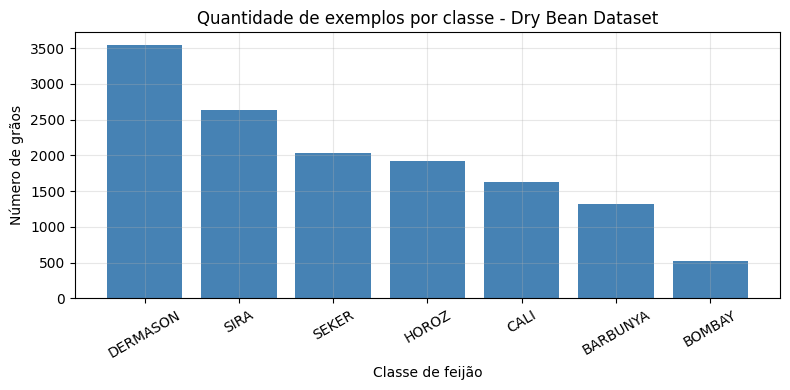

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(contagem.index, contagem.values, color="steelblue")
ax.set_title("Quantidade de exemplos por classe - Dry Bean Dataset")
ax.set_xlabel("Classe de feijão")
ax.set_ylabel("Número de grãos")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Interpretação do gráfico:** a altura de cada barra é o número de grãos da classe. Vemos claramente que DERMASON, SIRA e SEKER dominam o dataset, enquanto BOMBAY é pequena. Por isso, nos histogramas por classe a **escala vertical (frequência) não é comparável entre classes**: uma classe grande terá barras mais altas só por ter mais grãos.

<a id="a2"></a>
## A.2 — Escolha das features

Vamos usar **`Area`** e **`Perimeter`**, que são as sugeridas, **desde que os dados as confirmem como adequadas**. Para checar, calculamos para cada feature uma **estatística F (ANOVA)**: ela compara a diferença entre as médias das classes com a variação *dentro* de cada classe. Quanto maior o F, mais a feature separa as médias das classes. Também medimos a correlação entre `Area` e `Perimeter` e mostramos média, desvio, mínimo e máximo por classe.

**Significado das features (documentação do dataset):**
* **Area (A):** área da região do grão, medida como o número de pixels dentro de sua fronteira.
* **Perimeter (P):** circunferência do grão, isto é, o comprimento da sua borda.

In [7]:
classes = sorted(classe.unique())     # ordem alfabética fixa, usada em todos os gráficos

# Teste F (ANOVA): quanto maior, mais as médias das classes diferem em relação à variação dentro de cada classe
f_stat = {col: stats.f_oneway(*[X.loc[classe == c, col] for c in classes]).statistic for col in X.columns}
ranking = pd.Series(f_stat).sort_values(ascending=False).to_frame("estatística F")
ranking["posição"] = range(1, len(ranking) + 1)
display(ranking)

print("Correlação entre Area e Perimeter: %.3f" % X["Area"].corr(X["Perimeter"]))

resumo_classes = X.groupby(classe)[["Area", "Perimeter"]].agg(["mean", "std", "min", "max"]).round(1)
display(resumo_classes)

,estatística F,posição
Area,29017.5105,1
ConvexArea,28961.7912,2
EquivDiameter,25444.5478,3
Perimeter,24283.6637,4
MinorAxisLength,22442.3864,5
MajorAxisLength,21622.2379,6
ShapeFactor2,12329.8842,7
ShapeFactor1,12081.3211,8
AspectRatio,10376.9792,9
Compactness,10166.1179,10


Correlação entre Area e Perimeter: 0.967


Area                          Perimeter                       
              mean      std     min     max      mean    std     min     max
Class                                                                       
BARBUNYA   69804.1  10265.4   41487  115967    1046.1   89.6   759.6  1359.8
BOMBAY    173485.1  23327.7  114004  254616    1585.6  115.9  1265.9  1985.4
CALI       75538.2   9379.9   45504  116272    1057.6   67.6   789.8  1326.6
DERMASON   32118.7   4676.1   20420   42159     665.2   50.5   524.7   908.3
HOROZ      53648.5   7341.4   33006   81929     919.9   70.0   689.3  1162.6
SEKER      39881.3   4779.9   28395   61150     727.7   47.8   610.3   933.4
SIRA       44729.1   4546.8   31519   63612     796.4   44.4   668.1   984.3

### Explicação do resultado (A.2)

* `Area` tem a **maior estatística F entre as 16 features** (≈ 29.018, posição 1) e `Perimeter` ficou na **4ª posição** (≈ 24.284). Portanto, ambas estão entre as features que mais diferenciam as **médias** das classes — a escolha é compatível com os dados.
* A correlação entre `Area` e `Perimeter` é **≈ 0,967**, muito alta: grãos maiores têm, quase sempre, perímetro maior. Isso significa que as duas features **trazem informação parecida** (redundante). Em Machine Learning, isso é útil saber: usar as duas juntas não dobra a informação.
* A tabela por classe mostra médias de `Area` bem diferentes (DERMASON ≈ 32 mil px² até BOMBAY ≈ 173 mil px²), mas o desvio padrão de cada classe não é pequeno comparado à distância entre algumas médias (por exemplo SEKER ≈ 39,9 mil e SIRA ≈ 44,7 mil) — antecipando sobreposições.
* Um F alto **não garante** classificação correta: ele só diz que as médias diferem em relação à dispersão interna; as caudas das distribuições ainda podem se sobrepor.

<a id="a3"></a>
## A.3 — Primeiro conjunto de histogramas (10 bins)

**O que será feito:** um histograma de `Area` e outro de `Perimeter` para **cada uma das 7 classes** (14 painéis), em uma grade com **uma linha por classe** e **uma coluna por feature**.

**Por quê:** um histograma geral de todos os grãos misturaria as classes. Separando por classe, vemos a distribuição de cada variedade e podemos comparar posição, dispersão e sobreposição.

**Escolhas experimentais (não vêm do professor):** *10 bins* neste primeiro conjunto. O eixo horizontal é **compartilhado por coluna** (todas as classes de `Area` na mesma escala, e o mesmo para `Perimeter`) para que a posição de cada classe seja comparável. O número de bins é o mesmo em todos os painéis, mas a **largura** de cada bin depende do intervalo de valores da classe. A linha tracejada é a média da classe.

**Conceito:** um histograma divide o intervalo de valores em *bins* e conta quantos grãos caem em cada um; a altura da barra é a frequência.

In [34]:
def histogramas_por_classe(n_bins, features=("Area", "Perimeter")):
    """
    Cria 14 histogramas: 7 classes x 2 features.
    Para cada feature, todas as classes usam os mesmos limites de bins.
    density=True compara a forma das distribuições, sem favorecer classes maiores.
    """
    cores = plt.cm.tab10(np.arange(len(classes)))
    fig, eixos = plt.subplots(
        len(classes), len(features),
        figsize=(11, 2.3 * len(classes)),
        sharex="col"
    )

    # Limites comuns por feature: comparar classes usando a mesma escala e os mesmos bins.
    limites_por_feature = {
        feat: np.linspace(X[feat].min(), X[feat].max(), n_bins + 1)
        for feat in features
    }

    for i, nome_classe in enumerate(classes):
        for j, feat in enumerate(features):
            valores = X.loc[classe == nome_classe, feat].dropna()
            ax = eixos[i, j]
            ax.hist(
                valores,
                bins=limites_por_feature[feat],
                density=True,
                color=cores[i],
                edgecolor="black",
                linewidth=0.4
            )
            ax.axvline(valores.mean(), color="black", linestyle="--", linewidth=1)
            ax.set_ylabel(f"{nome_classe}\ndensidade", fontsize=8)

            if i == 0:
                ax.set_title(feat, fontsize=10)
            if i == len(classes) - 1:
                ax.set_xlabel(feat)

    fig.suptitle(
        f"Histogramas por classe — {n_bins} bins "
        "(linha tracejada = média da classe; eixo y = densidade)",
        y=1.0, fontsize=12
    )
    fig.tight_layout()
    return fig



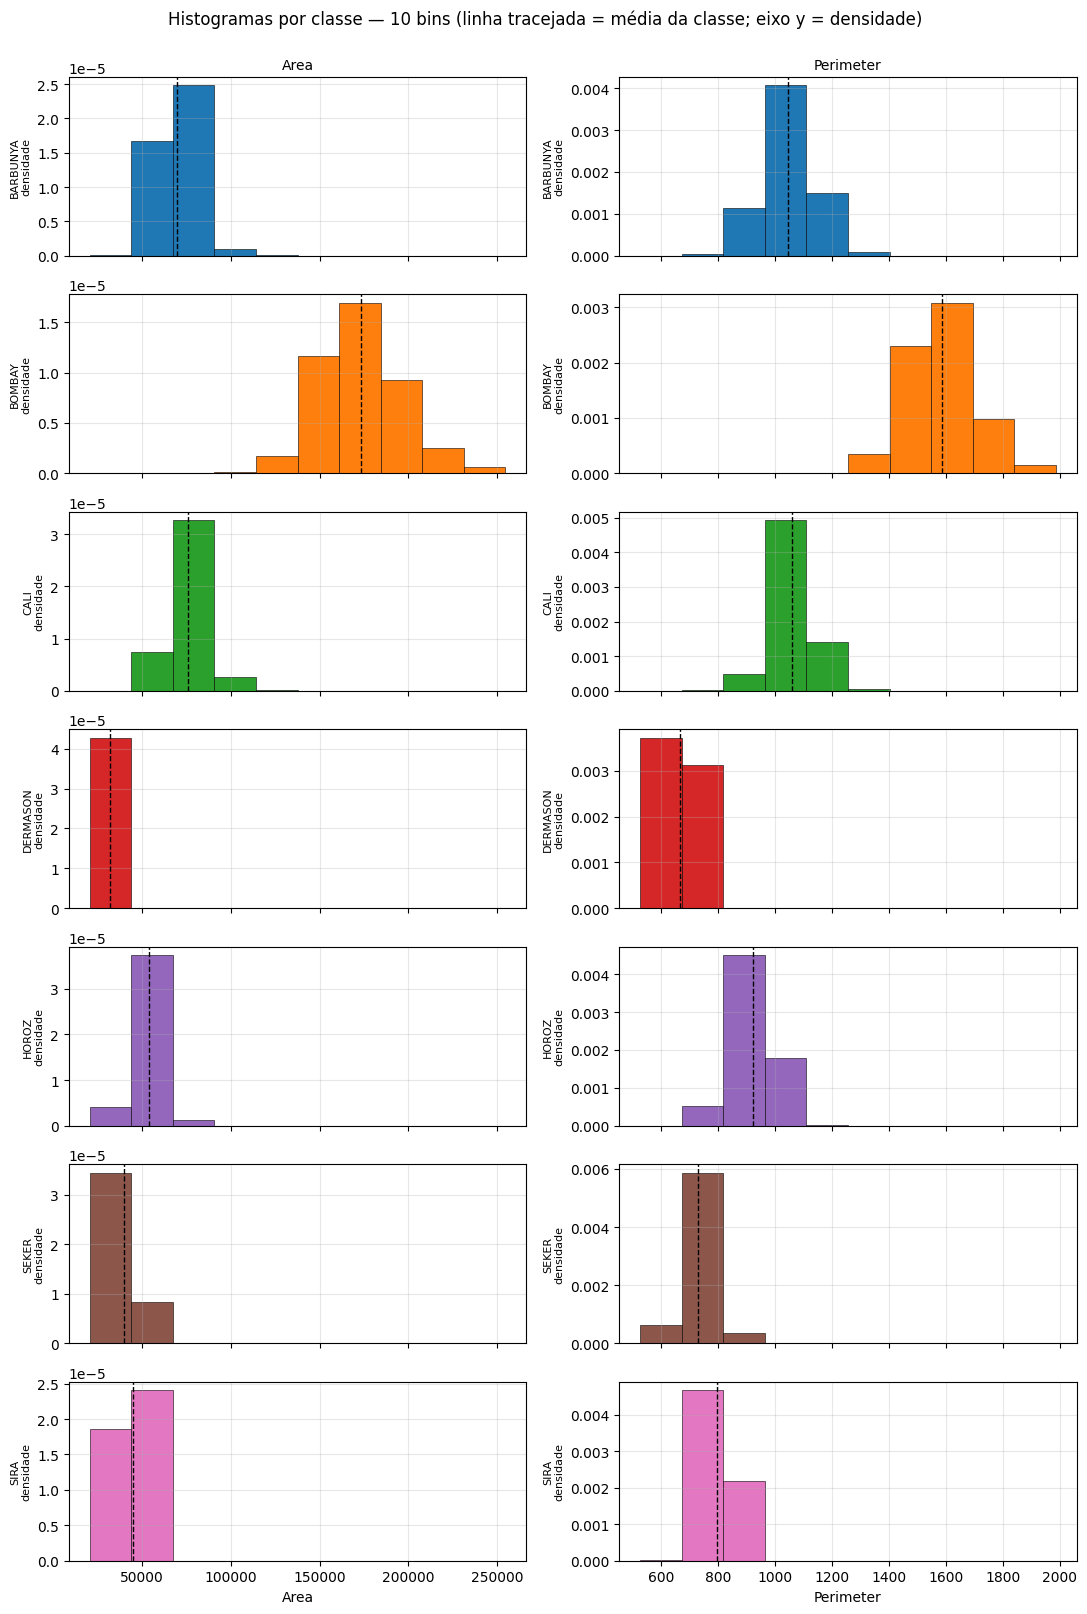

In [9]:
N_BINS_1 = 10   # escolha experimental: poucos bins
fig = histogramas_por_classe(N_BINS_1)
plt.show()

### Interpretação dos gráficos (A.3 — 10 bins)

Com 10 bins, o gráfico oferece uma visão mais geral das distribuições. Observe, para cada feature, onde ficam os picos, em que regiões as classes se sobrepõem e se alguma classe aparece deslocada para valores maiores ou menores.

A linha tracejada marca a média de cada classe. Como todas as classes usam os mesmos limites de bins por feature, as posições podem ser comparadas diretamente. Registre a interpretação final com base nos gráficos que aparecerem após executar esta célula; não conclua que uma classe pode ser identificada perfeitamente apenas pela inspeção visual.


<a id="a4"></a>
## A.4 — Segundo conjunto de histogramas (30 bins)

**O que será feito:** repetir **exatamente** a mesma grade — mesmas duas features, mesmas sete classes, mesmo eixo compartilhado e mesmos dados — mudando **apenas o número de bins** para **30** (escolha experimental). Assim, a diferença que aparecer é consequência do número de bins.

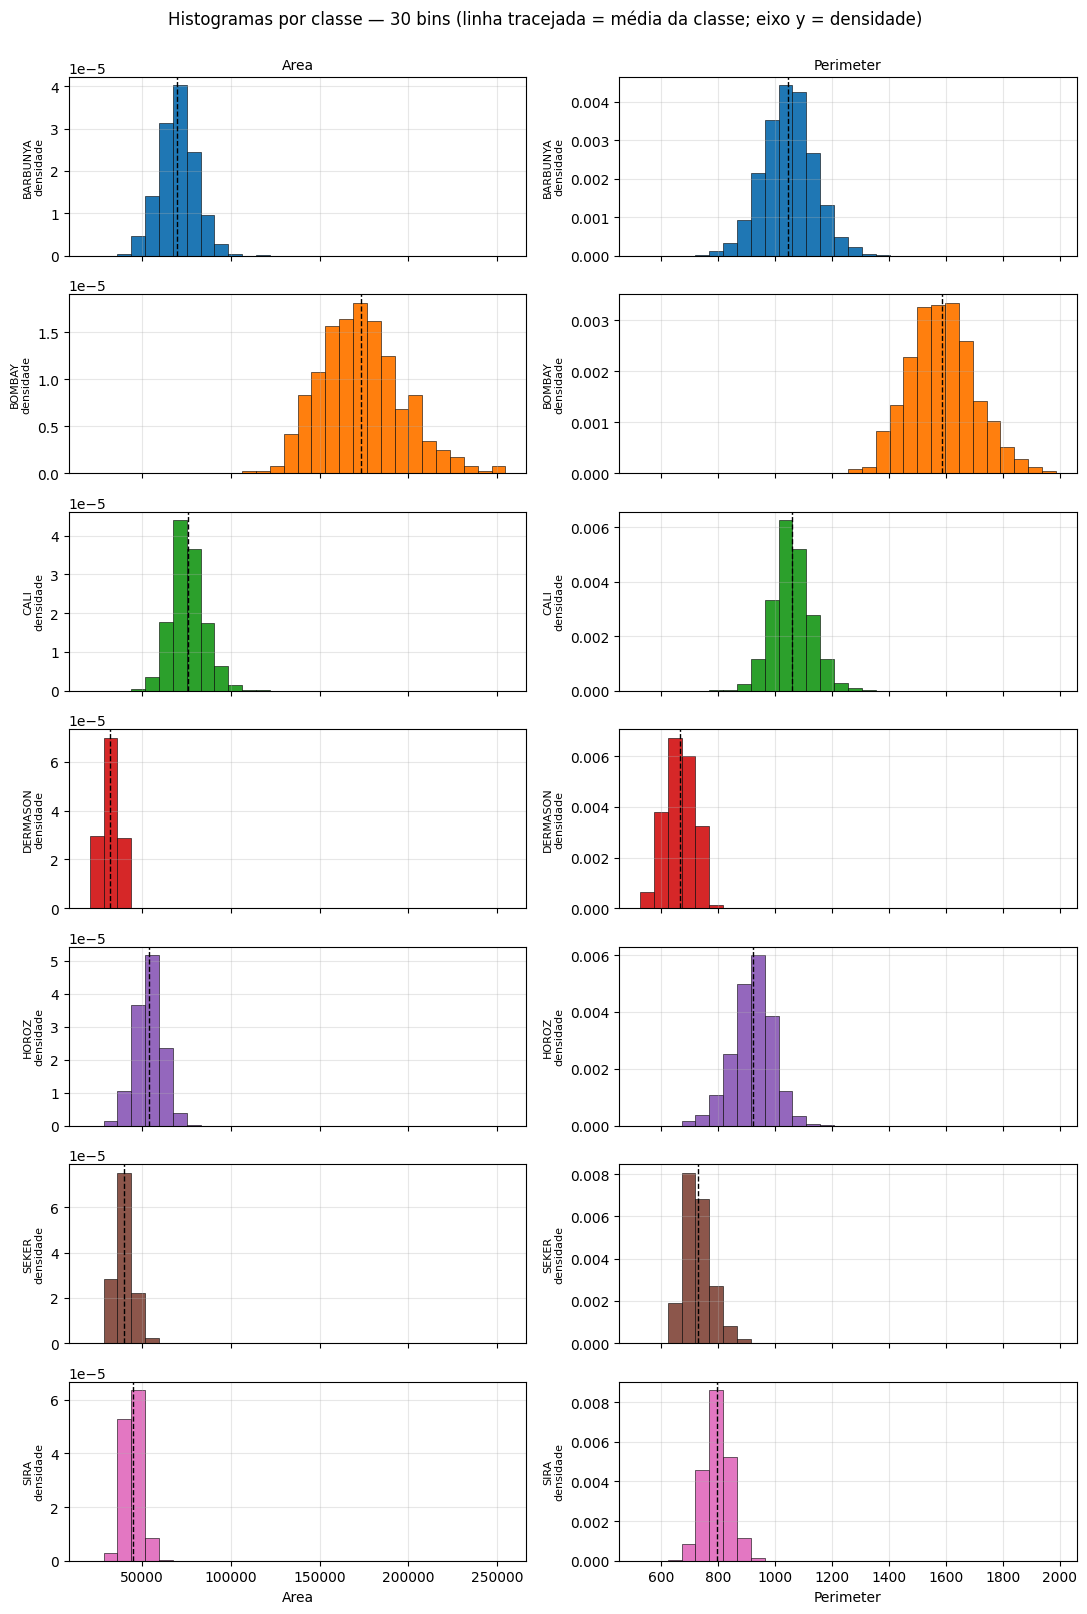

In [10]:
N_BINS_2 = 30   # escolha experimental: muitos bins (as mesmas features e as mesmas classes)
fig = histogramas_por_classe(N_BINS_2)
plt.show()

### Interpretação dos gráficos (A.4 — 30 bins)

Com 30 bins, os intervalos são mais estreitos e podem revelar detalhes que ficaram escondidos com 10 bins, como pequenas irregularidades, assimetrias ou picos locais. Ao mesmo tempo, o histograma pode parecer mais irregular.

Compare os gráficos de 10 e 30 bins mantendo a atenção nas mesmas features e classes. A posição geral das distribuições deve continuar semelhante, pois os dados não mudaram; o que muda é o nível de detalhe da representação. Baseie as observações específicas nos gráficos efetivamente produzidos.


Para sustentar a discussão sobre sobreposição com números (e não só com impressão visual), a célula abaixo conta, para cada feature, quantos pares de classes têm intervalos centrais (percentis 5 a 95) que se sobrepõem, e quantos valores extremos cada classe tem em `Area`.

In [7]:
# Indicador numérico de sobreposição: intervalo central (percentis 5 a 95) de cada classe
classes = sorted(classe.unique())

def intervalos_centrais(feat):
    return {c: (X.loc[classe == c, feat].quantile(0.05), X.loc[classe == c, feat].quantile(0.95)) for c in classes}

linhas = []
for feat in ["Area", "Perimeter"]:
    inter = intervalos_centrais(feat)
    pares_sobrepostos = []
    for a in range(len(classes)):
        for b in range(a + 1, len(classes)):
            ca, cb = classes[a], classes[b]
            if max(inter[ca][0], inter[cb][0]) <= min(inter[ca][1], inter[cb][1]):
                pares_sobrepostos.append(f"{ca}-{cb}")
    linhas.append({"feature": feat, "pares de classes (de 21)": 21, "pares com sobreposição P5-P95": len(pares_sobrepostos),
                   "quais": ", ".join(pares_sobrepostos)})
display(pd.DataFrame(linhas))

# Valores extremos (critério da caixa: além de 1,5 x IQR) por classe, feature Area
extremos = {}
for c in classes:
    v = X.loc[classe == c, "Area"]
    q1, q3 = v.quantile(0.25), v.quantile(0.75)
    extremos[c] = int(((v < q1 - 1.5 * (q3 - q1)) | (v > q3 + 1.5 * (q3 - q1))).sum())
print("Nº de valores extremos em Area (critério 1,5 x IQR):", extremos)

,feature,pares de classes (de 21),pares com sobreposição P5-P95,quais
0,Area,21,8,"BARBUNYA-CALI, BARBUNYA-HOROZ, CALI-HOROZ, DER..."
1,Perimeter,21,8,"BARBUNYA-CALI, BARBUNYA-HOROZ, CALI-HOROZ, DER..."


Nº de valores extremos em Area (critério 1,5 x IQR): {'BARBUNYA': 12, 'BOMBAY': 7, 'CALI': 29, 'DERMASON': 0, 'HOROZ': 23, 'SEKER': 37, 'SIRA': 14}


### Explicação do resultado (comparação entre bins e sobreposição)

**Efeito do número de bins**
- **10 bins:** visão mais resumida; facilita observar a forma geral, mas pode esconder detalhes.
- **30 bins:** mais detalhes locais, mas as barras podem ficar mais irregulares.
- Nesta implementação, cada feature usa os mesmos limites de bins em todas as classes. Assim, as classes são comparadas na mesma escala.
- Como os histogramas usam `density=True`, comparamos a forma das distribuições mesmo quando as classes têm quantidades diferentes de exemplos. Para comparar o tamanho das classes, use a tabela de contagens apresentada anteriormente.

**Classificação por Machine Learning:** uma feature pode ajudar a distinguir classes quando suas distribuições diferem, mas a sobreposição indica que essa feature isolada pode não ser suficiente. A classificação real deve considerar várias características e ser avaliada com métricas em dados de teste; histogramas são uma análise exploratória, não uma prova de desempenho do classificador.


<a id="a5"></a>
## A.5 — Análise detalhada e conclusão da Parte A

### Análise dos resultados

**Síntese.** O dataset tem 13.611 grãos, 16 features e 7 classes desbalanceadas (de 522 a 3.546 grãos). Os histogramas por classe mostram que as variedades ocupam **regiões diferentes** de `Area` e `Perimeter`, em geral com formato de sino, mas com **sobreposição** importante em 8 dos 21 pares de classes.

**Comparação entre as duas features.** `Area` teve a maior estatística F entre as 16 features (≈ 29.018) e `Perimeter` a 4ª (≈ 24.284). Os histogramas das duas são muito parecidos (correlação ≈ 0,967) e o padrão de sobreposição é o mesmo. Logo, as duas são adequadas para descrever o tamanho do grão, mas **são largamente redundantes**: juntas, não separam muito melhor que cada uma sozinha.

**Comparação entre bins.** Com 10 bins a forma geral é clara e estável; com 30 bins surgem detalhes e também ruído, especialmente em classes pequenas como BOMBAY. As conclusões principais (BOMBAY separada; DERMASON/SEKER/SIRA próximas; BARBUNYA/CALI/HOROZ próximas) foram as mesmas nos dois conjuntos.

**Implicações para Machine Learning.**
* Classes cujos histogramas **quase não se sobrepõem** (como BOMBAY) tendem a ser fáceis de separar usando só estas features.
* Onde há sobreposição (por exemplo SEKER × SIRA, ou BARBUNYA × CALI), um grão com área "típica" pode pertencer a mais de uma classe; um classificador baseado **apenas** nestas duas features tenderia a **confundir** essas classes. Para melhorar, seria preciso outras features — as de **forma** (como `roundness`, `Compactness`, `ShapeFactor1–4`) descrevem aspectos diferentes de tamanho e podem ajudar, mas **isso não foi testado aqui**.
* O desbalanceamento (BOMBAY com apenas 522 exemplos) também influencia o aprendizado.

**Limitações da análise visual.** Histogramas olham **uma feature por vez** (a combinação de duas features pode separar melhor do que cada uma sozinha); dependem do número de bins; as alturas não são comparáveis entre classes de tamanhos diferentes; e a sobreposição medida por percentis é um indicador simples, não uma medida de acurácia. **Nenhum classificador foi treinado**, então não podemos afirmar que uma feature "garante" uma classificação correta.

### Conclusão

`Area` e `Perimeter` são boas descritoras do tamanho dos grãos e separam bem algumas variedades (principalmente BOMBAY e, em menor grau, DERMASON), mas deixam **8 pares de classes com sobreposição relevante**. Os dois tamanhos de bins levam à mesma interpretação geral; 10 bins favorecem a visão global e 30 bins favorecem detalhes, com mais ruído. Para classificação por Machine Learning, estas duas features sozinhas seriam insuficientes para distinguir todas as classes, e features adicionais (sobretudo de forma) seriam necessárias.

<a id="parte-b"></a>
# Parte B — Z-score e tema de trabalho

### Figura do enunciado — Parte B

<p><b>Slide/página 13 do PDF:</b></p>
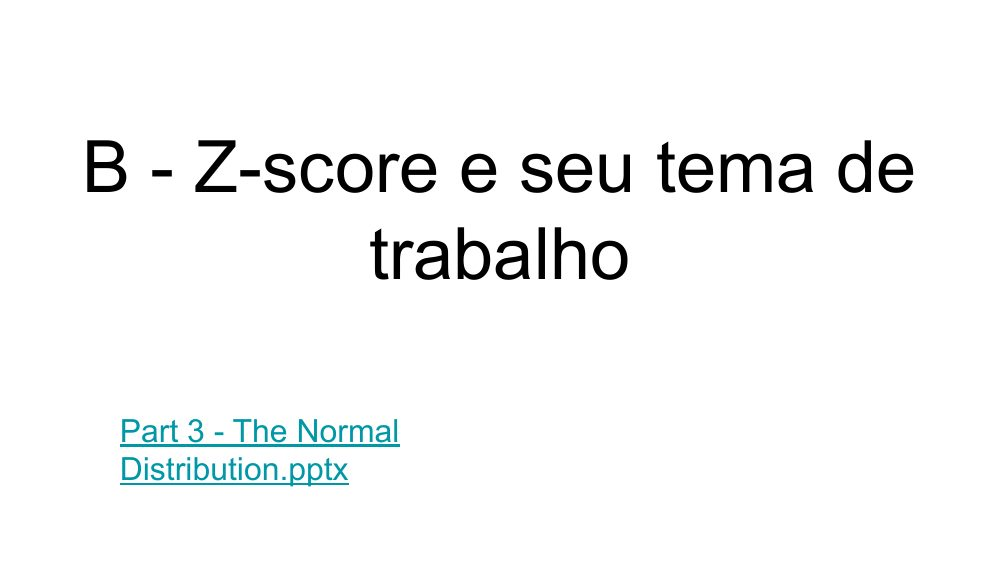

<p><b>Slide/página 14 do PDF:</b></p>
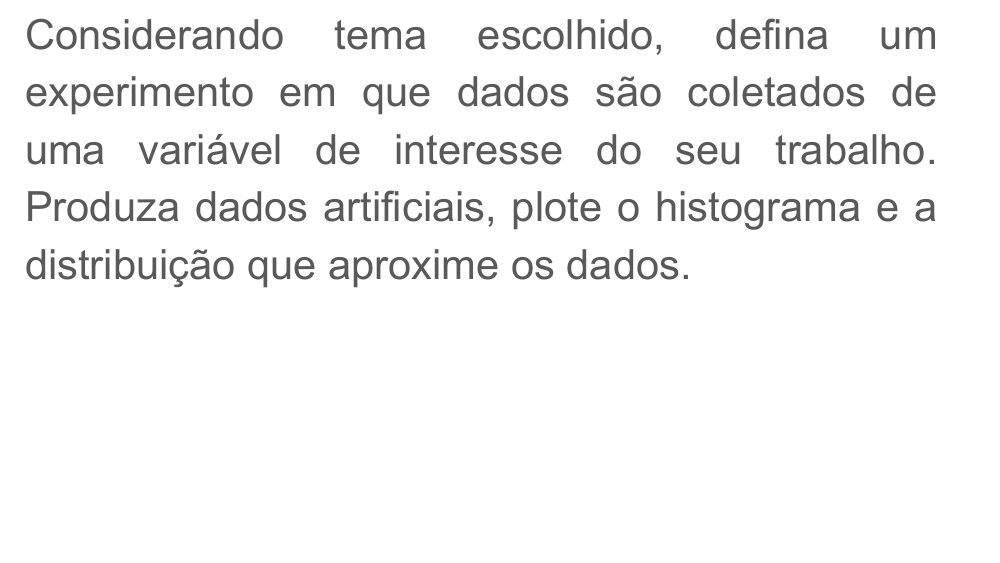

<p><b>Slide/página 15 do PDF:</b></p>
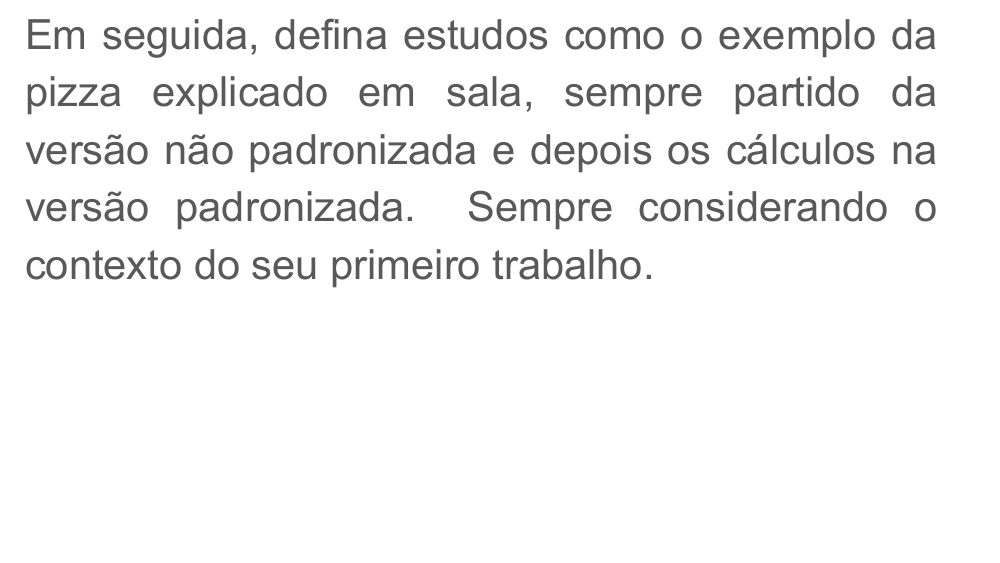

<p><b>Slide/página 16 do PDF:</b></p>
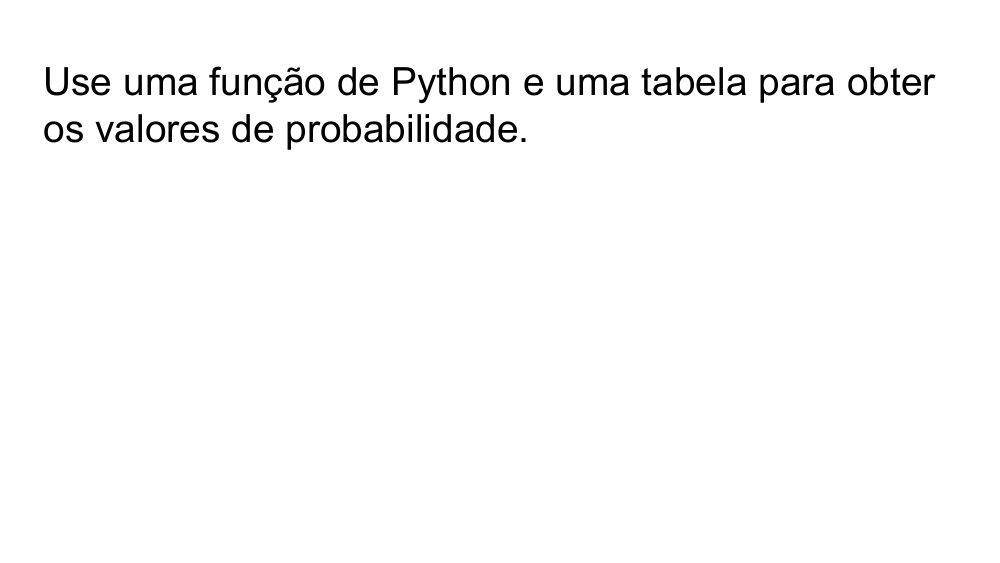



**Enunciado (resumo do PDF):** considerando o tema escolhido, definir um experimento em que dados são coletados de uma variável de interesse do seu trabalho; produzir dados artificiais, plotar o histograma e a distribuição que aproxime os dados; definir estudos como o **exemplo da pizza** explicado em sala, partindo da versão **não padronizada** e depois fazendo os cálculos na versão **padronizada**, sempre no contexto do primeiro trabalho; usar **uma função de Python e uma tabela** para obter os valores de probabilidade.

> ⚠️ **Limitação:** o *exemplo da pizza* foi explicado em sala e **não consta no PDF**. Não sabemos seus números nem a estrutura exata. Aqui seguimos a **estrutura descrita no enunciado** (escala original → padronização → comparação), com um tema e parâmetros **escolhidos por nós (hipóteses)**. Se o seu "primeiro trabalho" tiver outro tema (por exemplo, lucro mensal das empresas simuladas), basta trocar o nome da variável, as unidades e os parâmetros `MEDIA_VERDADEIRA` e `DESVIO_VERDADEIRO` na célula B.1.

## Tema e experimento

* **Tema (escolha):** desempenho de **campanhas de marketing digital**.
* **Experimento:** acompanhar **500 campanhas-dia** de anúncios e registrar, para cada uma, o **CTR** (*click-through rate*).
* **Variável de interesse:** CTR diário = (cliques ÷ impressões) × 100.
* **Unidade:** **porcentagem (%)**. Por exemplo, CTR = 2,5 % significa 2,5 cliques a cada 100 vezes que o anúncio foi exibido.
* **Por que é relevante:** o CTR mede o quanto o anúncio atrai atenção; é fácil de interpretar e permite perguntas práticas, como "qual a chance de uma campanha ter CTR abaixo da meta?".
* **Dados:** **100% artificiais (simulados)**, sem nenhum dado real ou privado.

<a id="b1"></a>
## B.1 — Produção dos dados artificiais

**O que será feito:** gerar 500 valores de CTR com `numpy`, usando uma **semente aleatória** (`default_rng(42)`) para reprodutibilidade.

**Hipótese de geração (escolha nossa):** CTR ~ Normal(μ = 2,4 %, σ = 0,5 p.p.). Essa é a "verdade" usada só para fabricar os dados. Nas etapas seguintes, **vamos tratar os dados como se não soubéssemos disso**: calcularemos média e desvio a partir dos dados e **testaremos** se a normal é razoável.

**Conceitos:** a **média** é o centro dos dados; o **desvio padrão** mede o quanto os valores costumam se afastar da média.

In [8]:
SEMENTE_B = 42
rng_b = np.random.default_rng(SEMENTE_B)

# Parâmetros usados APENAS para gerar os dados simulados (o "mundo verdadeiro" do experimento)
MEDIA_VERDADEIRA = 2.4      # CTR médio (%)
DESVIO_VERDADEIRO = 0.5     # desvio padrão do CTR (pontos percentuais)
N_OBS = 500                 # número de campanhas-dia observadas

ctr = rng_b.normal(MEDIA_VERDADEIRA, DESVIO_VERDADEIRO, N_OBS)   # dados artificiais
df_ctr = pd.DataFrame({"campanha_dia": np.arange(1, N_OBS + 1), "CTR_%": ctr.round(3)})

print("Primeiras observações (dados SIMULADOS):")
display(df_ctr.head(8))
print("Estatísticas descritivas:")
display(df_ctr["CTR_%"].describe().to_frame().T)

media_amostral = ctr.mean()
desvio_amostral = ctr.std(ddof=1)   # ddof=1: desvio padrão amostral
print(f"\nMédia amostral = {media_amostral:.4f} %  |  Desvio padrão amostral = {desvio_amostral:.4f} p.p.")
print(f"Menor valor = {ctr.min():.3f} % (não há CTR negativo: {bool(ctr.min() > 0)})")

Primeiras observações (dados SIMULADOS):


,campanha_dia,CTR_%
0,1,2.552
1,2,1.880
2,3,2.775
3,4,2.870
4,5,1.424
5,6,1.749
6,7,2.464
7,8,2.242


Estatísticas descritivas:


,count,mean,std,min,25%,50%,75%,max
CTR_%,500.0,2.3934,0.48,1.117,2.0663,2.4015,2.6935,3.857



Média amostral = 2.3934 %  |  Desvio padrão amostral = 0.4800 p.p.
Menor valor = 1.117 % (não há CTR negativo: True)


### Explicação do resultado (B.1)

A tabela mostra as primeiras campanhas simuladas e as estatísticas descritivas. Com a semente 42, a **média amostral** ficou muito próxima do valor usado na geração (2,4 %) e o **desvio padrão amostral** próximo de 0,5 p.p. A diferença é esperada: a amostra é finita, então suas estatísticas variam um pouco em torno dos parâmetros verdadeiros. O menor CTR simulado é positivo, portanto o modelo não produziu valores impossíveis (CTR negativo).

<a id="b2"></a>
## B.2 — Histograma e distribuição aproximada

**O que será feito:** (1) histograma dos dados; (2) curva da **distribuição normal** com média e desvio calculados dos dados, sobreposta ao histograma; (3) verificação da forma por **assimetria**, **curtose**, **teste de Shapiro-Wilk** e **gráfico Q-Q**.

**Por quê:** não vamos presumir normalidade — vamos avaliá-la. Para isso, o histograma é desenhado em **densidade** (a área total vale 1), a mesma escala da curva.

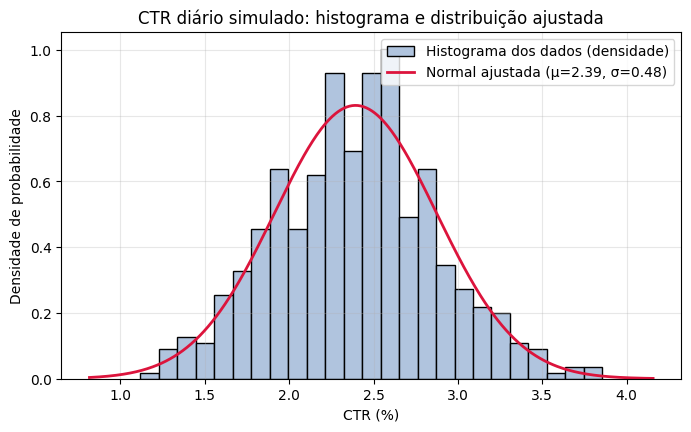

In [9]:
x_curva = np.linspace(ctr.min() - 0.3, ctr.max() + 0.3, 400)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(ctr, bins=25, density=True, color="lightsteelblue", edgecolor="black", label="Histograma dos dados (densidade)")
ax.plot(x_curva, stats.norm.pdf(x_curva, media_amostral, desvio_amostral), color="crimson", linewidth=2,
        label=f"Normal ajustada (μ={media_amostral:.2f}, σ={desvio_amostral:.2f})")
ax.set_title("CTR diário simulado: histograma e distribuição ajustada")
ax.set_xlabel("CTR (%)")
ax.set_ylabel("Densidade de probabilidade")
ax.legend()
plt.show()

**Interpretação do gráfico:** as barras são a **densidade observada** de CTR e a curva vermelha é a **densidade teórica** de uma normal com a média e o desvio dos dados. O histograma é simétrico em torno de ≈ 2,4 %, com a maior parte das campanhas entre ≈ 1,5 % e ≈ 3,3 %, e a curva acompanha bem a forma das barras. Diferenças pequenas entre barras e curva são variação aleatória de uma amostra de 500.

Assimetria (skewness): 0.093   (0 = simétrica)
Curtose em excesso:    -0.052   (0 = caudas como a normal)
Shapiro-Wilk: estatística = 0.9974, p-valor = 0.6330


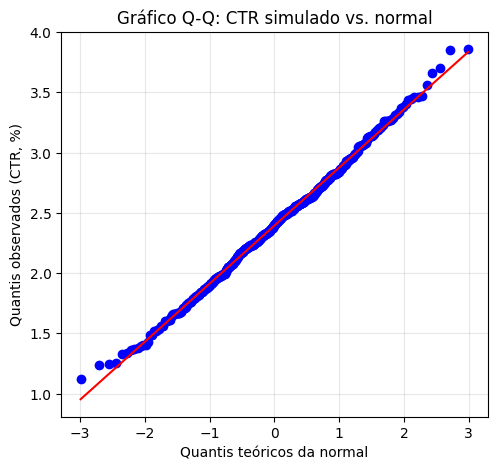

In [10]:
# Avaliando a forma ANTES de aceitar a normal
assimetria = stats.skew(ctr)
curtose_excesso = stats.kurtosis(ctr)          # 0 para uma normal
shapiro = stats.shapiro(ctr)
print(f"Assimetria (skewness): {assimetria:.3f}   (0 = simétrica)")
print(f"Curtose em excesso:    {curtose_excesso:.3f}   (0 = caudas como a normal)")
print(f"Shapiro-Wilk: estatística = {shapiro.statistic:.4f}, p-valor = {shapiro.pvalue:.4f}")

fig, ax = plt.subplots(figsize=(5.5, 5))
stats.probplot(ctr, dist="norm", plot=ax)      # gráfico Q-Q contra a normal
ax.set_title("Gráfico Q-Q: CTR simulado vs. normal")
ax.set_xlabel("Quantis teóricos da normal")
ax.set_ylabel("Quantis observados (CTR, %)")
plt.show()

**Interpretação do gráfico Q-Q e dos testes:** no Q-Q, se os dados fossem perfeitamente normais, os pontos ficariam sobre a reta. Aqui os pontos acompanham a reta de perto, com pequenos desvios nas pontas.
Os indicadores confirmam: **assimetria ≈ 0,09** e **curtose em excesso ≈ −0,05** (ambas próximas de 0) e **Shapiro-Wilk com p ≈ 0,63**. Como o p-valor é bem maior que 0,05, **não há evidência contra a normalidade**. (Isso não *prova* que seja normal, só que a normal é uma aproximação razoável.) Adotamos portanto a normal ajustada como modelo.

<a id="b3"></a>
## B.3 — Estudos na escala original

Todos os problemas abaixo começam **na escala original (CTR em %)**, usando a normal ajustada com **μ = média amostral** e **σ = desvio amostral**. A cada problema comparamos também com a **frequência observada** nos 500 dados (que é uma frequência, não uma probabilidade teórica).

| # | Enunciado contextualizado | Informação disponível | Cálculo |
|---|---|---|---|
| 1 | A meta mínima de CTR é 2,0 %. Qual a probabilidade de uma campanha ficar **abaixo** da meta? | μ, σ do CTR | P(X < 2,0) = `cdf(2,0)` |
| 2 | Campanhas com CTR acima de 3,0 % são consideradas excelentes. Qual a probabilidade de uma campanha ser excelente? | μ, σ | P(X > 3,0) = 1 − `cdf(3,0)` |
| 3 | Qual a probabilidade de o CTR ficar **entre** 2,0 % e 3,0 %? | μ, σ | `cdf(3,0)` − `cdf(2,0)` |
| 4 | Qual CTR separa os 10% **melhores** campanhas dos demais (percentil 90)? | μ, σ | `ppf(0,90)` |

In [11]:
mu, sigma = media_amostral, desvio_amostral    # parâmetros da normal ajustada

LIM_BAIXO, LIM_ALTO, PERCENTIL = 2.0, 3.0, 0.90

# Problema 1: P(X < 2,0)       Problema 2: P(X > 3,0)       Problema 3: P(2,0 < X < 3,0)
p1 = stats.norm.cdf(LIM_BAIXO, loc=mu, scale=sigma)
p2 = 1 - stats.norm.cdf(LIM_ALTO, loc=mu, scale=sigma)
p3 = stats.norm.cdf(LIM_ALTO, loc=mu, scale=sigma) - stats.norm.cdf(LIM_BAIXO, loc=mu, scale=sigma)
# Problema 4: valor de CTR que deixa 90% das campanhas abaixo dele (percentil 90)
x90 = stats.norm.ppf(PERCENTIL, loc=mu, scale=sigma)

# Frequências observadas nos dados (apenas para comparar com o modelo)
f1 = np.mean(ctr < LIM_BAIXO)
f2 = np.mean(ctr > LIM_ALTO)
f3 = np.mean((ctr > LIM_BAIXO) & (ctr < LIM_ALTO))
f4 = np.quantile(ctr, PERCENTIL)

escala_original = pd.DataFrame({
    "problema": ["1) P(CTR < 2,0)", "2) P(CTR > 3,0)", "3) P(2,0 < CTR < 3,0)", "4) CTR do percentil 90 (valor, %)"],
    "modelo normal (escala original)": [p1, p2, p3, x90],
    "observado nos dados": [f1, f2, f3, f4],
})
display(escala_original)

,problema,modelo normal (escala original),observado nos dados
0,"1) P(CTR < 2,0)",0.2062,0.2220
1,"2) P(CTR > 3,0)",0.1032,0.1020
2,"3) P(2,0 < CTR < 3,0)",0.6907,0.6760
3,"4) CTR do percentil 90 (valor, %)",3.0085,3.0038


### Explicação do resultado (B.3)

* **Problema 1:** a probabilidade de CTR abaixo de 2,0 % é ≈ **20,6 %** pelo modelo (observado nos dados: 22,2 %): cerca de 1 em cada 5 campanhas fica abaixo da meta.
* **Problema 2:** ≈ **10,3 %** de chance de CTR acima de 3,0 % (observado: 10,2 %).
* **Problema 3:** ≈ **69,1 %** das campanhas ficam entre 2,0 % e 3,0 % (observado: 67,6 %).
* **Problema 4:** o percentil 90 é ≈ **3,01 %**: só 10 % das campanhas superam esse valor (observado: 3,00 %).

O modelo e os dados concordam dentro de pequenas diferenças esperadas por variação amostral. Note que os resultados 1 e 2 são **probabilidades de cauda** e o 3 é **probabilidade de intervalo**; o 4 não é probabilidade, mas um **valor de CTR (quantil)**.

<a id="b4"></a>
## B.4 — Padronização com Z-score

A fórmula é:

$$z = \frac{x - \mu}{\sigma}$$

* **x:** o valor original (aqui, um CTR em %).
* **μ (mu):** a média da distribuição.
* **σ (sigma):** o desvio padrão da distribuição.
* **z:** quantos desvios padrão o valor x está acima ou abaixo da média.

**Como interpretar o sinal de z:**
* **z > 0:** x está **acima** da média (z = 1 significa 1 desvio padrão acima).
* **z < 0:** x está **abaixo** da média.
* **z = 0:** x é **exatamente igual** à média.

Depois de padronizar, os valores seguem a **normal padrão N(0, 1)**, e as probabilidades podem ser lidas em uma única tabela. Abaixo resolvemos **os mesmos 4 problemas** usando somente z e comparamos com a escala original.

In [12]:
# z = (x - mu) / sigma
def zscore(x, mu, sigma):
    return (x - mu) / sigma

z_baixo = zscore(LIM_BAIXO, mu, sigma)
z_alto = zscore(LIM_ALTO, mu, sigma)
print(f"z(2,0) = ({LIM_BAIXO} - {mu:.3f}) / {sigma:.3f} = {z_baixo:.3f}")
print(f"z(3,0) = ({LIM_ALTO} - {mu:.3f}) / {sigma:.3f} = {z_alto:.3f}")

# Agora usando SOMENTE a normal padrão N(0, 1)
q1 = stats.norm.cdf(z_baixo)                       # P(Z < z_baixo)
q2 = 1 - stats.norm.cdf(z_alto)                    # P(Z > z_alto)
q3 = stats.norm.cdf(z_alto) - stats.norm.cdf(z_baixo)
z90 = stats.norm.ppf(PERCENTIL)                    # z do percentil 90
x90_padr = mu + z90 * sigma                        # volta para a escala original: x = mu + z*sigma

comparacao = pd.DataFrame({
    "problema": escala_original["problema"],
    "escala original": [p1, p2, p3, x90],
    "escala padronizada": [q1, q2, q3, x90_padr],
})
comparacao["diferença"] = (comparacao["escala original"] - comparacao["escala padronizada"]).abs()
display(comparacao)
print(f"z do percentil 90 = {z90:.4f}")

z(2,0) = (2.0 - 2.393) / 0.480 = -0.820
z(3,0) = (3.0 - 2.393) / 0.480 = 1.264


,problema,escala original,escala padronizada,diferença
0,"1) P(CTR < 2,0)",0.2062,0.2062,0.0
1,"2) P(CTR > 3,0)",0.1032,0.1032,0.0
2,"3) P(2,0 < CTR < 3,0)",0.6907,0.6907,0.0
3,"4) CTR do percentil 90 (valor, %)",3.0085,3.0085,0.0


z do percentil 90 = 1.2816


### Explicação do resultado (B.4)

* A meta de 2,0 % tem **z ≈ −0,82**: está cerca de 0,82 desvio padrão **abaixo** da média. O limite de 3,0 % tem **z ≈ +1,26**: cerca de 1,26 desvio **acima**.
* A coluna "diferença" é **zero** (a menos de arredondamento computacional): as duas escalas dão **exatamente o mesmo resultado**. A padronização não muda a probabilidade, só muda a régua.
* No problema 4, obtemos z90 ≈ 1,2816 na normal padrão e voltamos à escala original com x = μ + z·σ, recuperando ≈ 3,01 %.

<a id="b5"></a>
## B.5 — Função Python e tabela de probabilidades

O professor pede explicitamente **uma função de Python e uma tabela** para obter probabilidades. Abaixo:
1. a função `probabilidade_normal(mu, sigma, a, b)`, que usa `scipy.stats.norm` (`cdf` = probabilidade **acumulada** até x; `sf` = probabilidade de **cauda direita**, igual a 1 − cdf);
2. **Tabela 1:** valores originais de CTR, seus z-scores e as probabilidades correspondentes (acumulada, cauda direita e intervalo central);
3. **Tabela 2:** a clássica **tabela da normal padrão**, com P(Z ≤ z).

In [13]:
def probabilidade_normal(mu, sigma, a=None, b=None):
    """Probabilidades de uma normal N(mu, sigma) em intervalos.
    - só a  -> P(X <= a) e P(X > a);   - a e b -> P(a < X < b)."""
    if a is not None and b is None:
        return {"P(X <= a)": stats.norm.cdf(a, mu, sigma), "P(X > a)": stats.norm.sf(a, mu, sigma)}
    if a is not None and b is not None:
        return {"P(a < X < b)": stats.norm.cdf(b, mu, sigma) - stats.norm.cdf(a, mu, sigma)}
    raise ValueError("Informe ao menos o valor a.")

print(probabilidade_normal(mu, sigma, a=LIM_BAIXO))
print(probabilidade_normal(mu, sigma, a=LIM_BAIXO, b=LIM_ALTO))

# Tabela 1: valores originais, Z-scores e probabilidades
valores_x = [1.0, 1.5, 2.0, 2.4, 2.8, 3.0, 3.5, 4.0]
tabela_x = pd.DataFrame({"CTR x (%)": valores_x})
tabela_x["z = (x-μ)/σ"] = zscore(tabela_x["CTR x (%)"], mu, sigma)
tabela_x["P(X ≤ x)  [acumulada]"] = stats.norm.cdf(tabela_x["z = (x-μ)/σ"])
tabela_x["P(X > x)  [cauda direita]"] = 1 - tabela_x["P(X ≤ x)  [acumulada]"]
tabela_x["P(μ-|x-μ| < X < μ+|x-μ|)  [intervalo central]"] = 2 * stats.norm.cdf(tabela_x["z = (x-μ)/σ"].abs()) - 1
display(tabela_x.round(4))

# Tabela 2: tabela da normal padrão (probabilidades acumuladas P(Z <= z))
z_valores = np.round(np.arange(-3, 3.01, 0.5), 1)
tabela_z = pd.DataFrame({"z": z_valores, "P(Z ≤ z)": stats.norm.cdf(z_valores)})
display(tabela_z.round(4))

{'P(X <= a)': np.float64(0.20618886691188876), 'P(X > a)': np.float64(0.7938111330881112)}
{'P(a < X < b)': np.float64(0.6906530060443437)}


,CTR x (%),z = (x-μ)/σ,P(X ≤ x) [acumulada],P(X > x) [cauda direita],P(μ-|x-μ| < X < μ+|x-μ|) [intervalo central]
0,1.0,-2.9032,0.0018,0.9982,0.9963
1,1.5,-1.8615,0.0313,0.9687,0.9373
2,2.0,-0.8197,0.2062,0.7938,0.5876
3,2.4,0.0137,0.5055,0.4945,0.0109
4,2.8,0.8471,0.8015,0.1985,0.6030
5,3.0,1.2638,0.8968,0.1032,0.7937
6,3.5,2.3055,0.9894,0.0106,0.9789
7,4.0,3.3472,0.9996,0.0004,0.9992


,z,P(Z ≤ z)
0,-3.0,0.0013
1,-2.5,0.0062
2,-2.0,0.0228
3,-1.5,0.0668
4,-1.0,0.1587
5,-0.5,0.3085
6,0.0,0.5000
7,0.5,0.6915
8,1.0,0.8413
9,1.5,0.9332


### Explicação do resultado (B.5)

* **Como ler a Tabela 1:** cada linha é um CTR *x*. A coluna *z* o padroniza. **P(X ≤ x)** é a probabilidade **acumulada** (de ser menor ou igual a x); **P(X > x)** é a **cauda direita**; a última coluna é a probabilidade de um valor cair no **intervalo central** simétrico em torno da média com a mesma distância |x − μ|. Por exemplo, CTR = 3,0 % tem z ≈ 1,26, P(X ≤ x) ≈ 0,897 e P(X > x) ≈ 0,103, coerente com o problema 2.
* **Como ler a Tabela 2:** para um z, ela dá P(Z ≤ z). Por exemplo, P(Z ≤ 1) ≈ 0,8413 e P(Z ≤ −1) ≈ 0,1587; a diferença, ≈ 0,683, é a probabilidade de ficar a menos de 1 desvio padrão da média.
* Valores extremos como CTR = 4,0 % (z ≈ 3,35) têm probabilidade de cauda inferior a 0,1 %.

O gráfico abaixo mostra a **mesma área** (problema 3) nas duas escalas, para visualizar que a padronização só reescala o eixo horizontal.

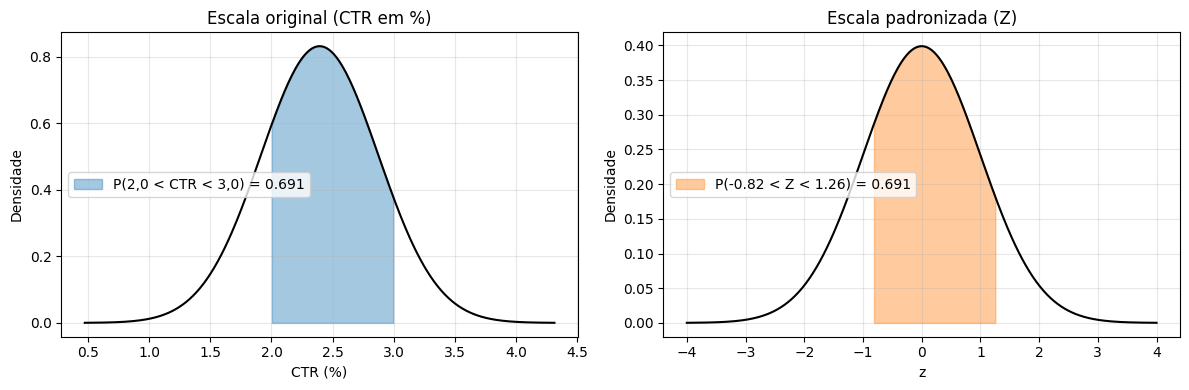

In [14]:
fig, eixos = plt.subplots(1, 2, figsize=(12, 4))
xx = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 400)
# Esquerda: escala original, probabilidade do Problema 3
eixos[0].plot(xx, stats.norm.pdf(xx, mu, sigma), color="black")
mascara = (xx > LIM_BAIXO) & (xx < LIM_ALTO)
eixos[0].fill_between(xx[mascara], stats.norm.pdf(xx[mascara], mu, sigma), color="tab:blue", alpha=0.4,
                      label=f"P(2,0 < CTR < 3,0) = {p3:.3f}")
eixos[0].set_title("Escala original (CTR em %)")
eixos[0].set_xlabel("CTR (%)"); eixos[0].set_ylabel("Densidade"); eixos[0].legend()
# Direita: mesma área na escala padronizada
zz = (xx - mu) / sigma
eixos[1].plot(zz, stats.norm.pdf(zz), color="black")
mz = (zz > z_baixo) & (zz < z_alto)
eixos[1].fill_between(zz[mz], stats.norm.pdf(zz[mz]), color="tab:orange", alpha=0.4,
                      label=f"P({z_baixo:.2f} < Z < {z_alto:.2f}) = {q3:.3f}")
eixos[1].set_title("Escala padronizada (Z)")
eixos[1].set_xlabel("z"); eixos[1].set_ylabel("Densidade"); eixos[1].legend()
plt.tight_layout(); plt.show()

**Interpretação do gráfico:** à esquerda, a área azul entre 2,0 % e 3,0 % na escala original; à direita, a área laranja entre z ≈ −0,82 e z ≈ 1,26 na normal padrão. O formato da curva é o mesmo e **as duas áreas valem ≈ 0,69**, mostrando que probabilidade é área e que ela não muda com a padronização.

<a id="b6"></a>
## B.6 — Análise detalhada e conclusão da Parte B

### Análise dos resultados

* **Interpretação do Z-score:** z diz **quantos desvios padrão** um valor está da média. Isso permite comparar posições mesmo em variáveis de unidades diferentes (por exemplo, CTR em % e custo em R$).
* **Escala original × padronizada:** os quatro problemas deram **resultados idênticos** nas duas escalas, como deve ser. A vantagem da escala padronizada é que **uma única tabela** (a da N(0,1)) serve para qualquer média e desvio.
* **Modelo × dados:** as probabilidades do modelo (20,6 %, 10,3 %, 69,1 %) ficaram próximas das frequências observadas (22,2 %, 10,2 %, 67,6 %). Como os dados são simulados e a amostra tem 500 observações, diferenças de 1 a 2 pontos percentuais são compatíveis com variação aleatória.
* **Ajuste da normal:** assimetria e curtose próximas de zero, Shapiro-Wilk com p ≈ 0,63 e Q-Q alinhado indicam que a normal é uma aproximação razoável **para estes dados simulados**.

### Limitações

* A normal tem suporte em toda a reta real, incluindo CTR negativo, que é impossível; aqui a probabilidade disso é desprezível (o menor CTR simulado foi positivo e μ está a mais de 4,9 σ de zero), mas para médias próximas de zero isso seria um problema.
* Os dados são **artificiais** e foram gerados a partir de uma normal; é natural, portanto, que a normal se ajuste bem. Com dados reais de campanhas (frequentemente assimétricos), o ajuste precisaria ser reavaliado.
* O teste de Shapiro-Wilk não prova normalidade: apenas não a rejeitou.
* O exemplo da pizza da aula não foi reproduzido, pois seus detalhes não estão no PDF.

### Conclusão

Definimos um experimento de CTR em campanhas de marketing digital, geramos 500 observações simuladas, verificamos que a normal é uma aproximação razoável e resolvemos quatro problemas de probabilidade primeiro na escala original e depois padronizada, com resultados idênticos. A função `probabilidade_normal` e as duas tabelas permitem obter probabilidades acumuladas, de cauda e de intervalo, atendendo ao requisito do professor.

<a id="parte-c"></a>
# Parte C — Distribuição Binomial

### Figura do enunciado — Parte C

<p><b>Slide/página 17 do PDF:</b></p>
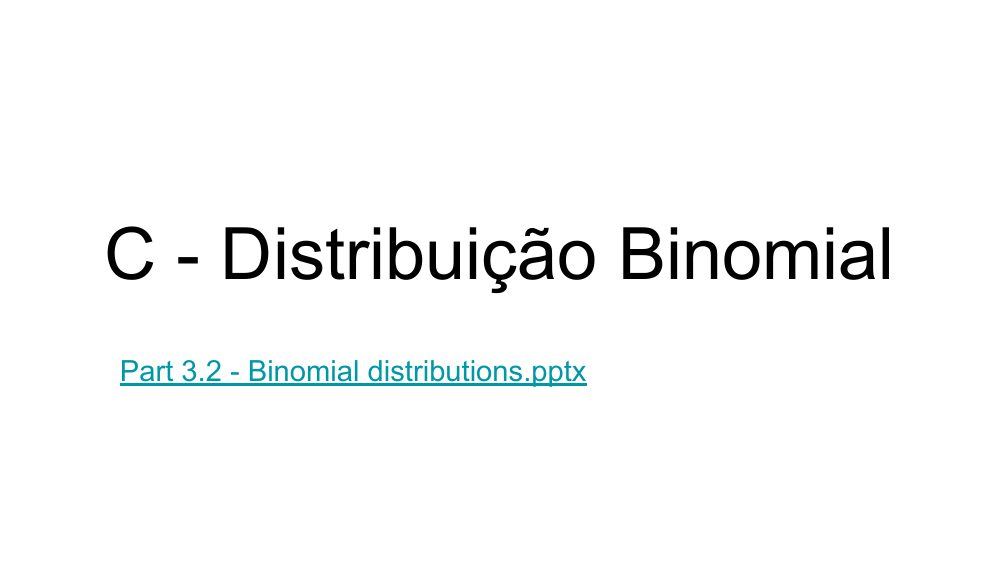

<p><b>Slide/página 20 do PDF:</b></p>
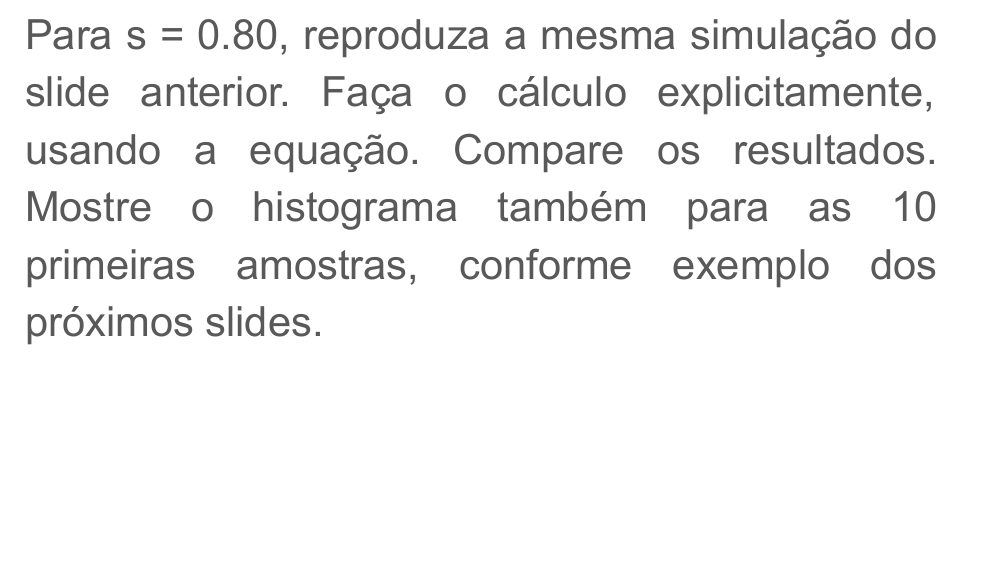



**Enunciado (resumo do PDF):** *"Para s = 0.80, reproduza a mesma simulação do slide anterior. Faça o cálculo explicitamente, usando a equação. Compare os resultados. Mostre o histograma também para as 10 primeiras amostras, conforme exemplo dos próximos slides."*

### O que o PDF permite confirmar sobre o experimento
Os slides da Parte C **estão no PDF** e mostram: (i) uma simulação com **s = 0,95**, amostras de **50 tentativas** (✓/✗), **"Total samples: 242,485"** e destaque para **P(48 ✓, 2 ✗ | s = 0,95) = 26,1 %**; (ii) a equação binomial $P_x = \binom{n}{x} p^x q^{n-x}$; (iii) amostras de **10 tentativas**, em que cada tentativa é um **número entre 0 e 1** (0,55; 0,72; 0,96 ...), marcado ✓ se for **menor que s** e ✗ caso contrário (ex.: 0,96, 0,97 e 0,98 são ✗ com s = 0,95), formando um histograma da contagem de ✓ por amostra (0 a 10).

### Interpretações e hipóteses (explícitas)
* **`s` = probabilidade de sucesso por tentativa** (é o `p` da equação). Isso é **inferido dos valores mostrados nos slides** (✓ para números abaixo de s). A **definição verbal** de `s` foi dada em sala e não está escrita no PDF; se o professor usou outra, ajuste `s`.
* **"Amostra"** (na simulação de 10 tentativas) = **um grupo de 10 tentativas**; o histograma mostra, para cada uma das 10 primeiras amostras, **quantos ✓** ela teve.
* **Não consta no PDF:** a semente aleatória e o gerador usados no vídeo da aula. Usamos sementes nossas, então os números exatos **não serão iguais** aos do slide — apenas as probabilidades teóricas.
* **242.485 amostras** na simulação grande para s = 0,80 é uma **cópia do "Total samples" do slide** (escolha nossa para facilitar a comparação).

<a id="c1"></a>
## C.1 — Definição do experimento

* **Tentativa:** sortear um número uniforme em [0, 1] e comparar com `s`.
* **Sucesso (✓):** o número sorteado é **menor que s**. **Fracasso (✗):** o número é maior ou igual a `s`.
* **Número de tentativas por amostra:** n = **50** (simulação grande) e n = **10** (exemplo das 10 primeiras amostras), como nos slides.
* **Probabilidade de sucesso:** p = s (0,95 no slide original; **0,80** no que o professor pede).
* **Por que é binomial:** (1) número **fixo** de tentativas; (2) cada tentativa tem **dois resultados** (sucesso/fracasso); (3) a probabilidade de sucesso é a **mesma** em todas; (4) as tentativas são **independentes**. A variável X = "número de sucessos em n tentativas" segue Binomial(n, p).

**Equação:** $P(X = k) = \binom{n}{k}\, p^k\, (1-p)^{n-k}$, onde $\binom{n}{k} = \frac{n!}{k!\,(n-k)!}$ é o número de maneiras de escolher quais tentativas serão sucesso, $p^k$ a probabilidade dos k sucessos e $(1-p)^{n-k}$ a dos fracassos restantes.

<a id="c2"></a>
## C.2 — Simulação

**O que será feito:** definir funções reutilizáveis e rodar primeiro a simulação do **slide original (s = 0,95, n = 50)**. Isso serve de **validação**: se o código estiver correto, a frequência simulada de 48 sucessos deve ficar perto de 26,1 %. Com semente fixa (`default_rng(123)`) a simulação é reproduzível.

Funções: `probabilidade_binomial` (equação explícita), `simula_amostras` (simulação com números uniformes), `texto_amostra` (mostra ✓/✗) e `histograma_binomial` (gráfico).

In [15]:
def probabilidade_binomial(k, n, p):
    """P(X = k) = C(n,k) * p^k * (1-p)^(n-k), calculada explicitamente pela equação."""
    return math.comb(n, k) * p**k * (1 - p) ** (n - k)

def simula_amostras(n_tentativas, s, n_amostras, rng):
    """Reproduz a simulação dos slides: em cada tentativa sorteia-se um número uniforme em [0, 1];
    se o número for menor que s, a tentativa é um sucesso (✓); caso contrário, é um fracasso (✗)."""
    sorteios = rng.random((n_amostras, n_tentativas))
    sucessos = sorteios < s
    return sorteios, sucessos, sucessos.sum(axis=1)

def texto_amostra(sorteio, sucesso):
    """Mostra uma amostra no estilo dos slides: ✓ ou ✗ para cada tentativa."""
    return " ".join("✓" if ok else "✗" for ok in sucesso)

def histograma_binomial(contagens, n, s, k_destaque, titulo):
    """Frequência relativa (%) do nº de sucessos por amostra, com a probabilidade teórica sobreposta."""
    ks = np.arange(0, n + 1)
    freq = np.bincount(contagens, minlength=n + 1) / len(contagens) * 100
    teorica = np.array([probabilidade_binomial(k, n, s) for k in ks]) * 100
    cores = ["tab:green" if k == k_destaque else "lightgray" for k in ks]
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.bar(ks, freq, color=cores, edgecolor="black", linewidth=0.4, label="Frequência simulada (%)")
    ax.plot(ks, teorica, "o", color="crimson", markersize=4, label="Probabilidade teórica (equação) (%)")
    ax.set_xlim(max(0, int(n * s - 6 * math.sqrt(n * s * (1 - s)))) - 1, n + 1)
    ax.set_title(titulo)
    ax.set_xlabel("Número de sucessos (✓) em cada amostra")
    ax.set_ylabel("Porcentagem das amostras (%)")
    ax.legend()
    return fig

In [16]:
N_TENTATIVAS = 50          # n do slide: 50 tentativas por amostra
N_AMOSTRAS = 242_485       # "Total samples" mostrado no slide
rng_c = np.random.default_rng(123)

s = 0.95                   # reproduz primeiro o slide original (validação do código)
sorteios, sucessos, contagens95 = simula_amostras(N_TENTATIVAS, s, N_AMOSTRAS, rng_c)

print(f"Parâmetros: n = {N_TENTATIVAS} tentativas por amostra, s = {s}, amostras = {N_AMOSTRAS:,}")
print("Primeira amostra (✓ = sucesso, ✗ = fracasso):")
print(texto_amostra(sorteios[0], sucessos[0]), "->", contagens95[0], "sucessos")
print("Primeiros sorteios uniformes:", sorteios[0, :6].round(2))
print("Primeiras 15 contagens de sucessos:", contagens95[:15])

Parâmetros: n = 50 tentativas por amostra, s = 0.95, amostras = 242,485
Primeira amostra (✓ = sucesso, ✗ = fracasso):
✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ -> 50 sucessos
Primeiros sorteios uniformes: [0.68 0.05 0.22 0.18 0.18 0.81]
Primeiras 15 contagens de sucessos: [50 49 47 48 45 48 47 49 48 45 45 48 46 50 47]


### Explicação do resultado (C.2)

A primeira amostra mostra o mecanismo: cada tentativa recebe um sorteio entre 0 e 1 e vira ✓ ou ✗ conforme ele seja menor ou não que 0,95. Já a lista das primeiras contagens mostra que o número de sucessos **varia de amostra para amostra** (valores como 45 a 50), concentrando-se perto de 48 — o mesmo comportamento do slide.

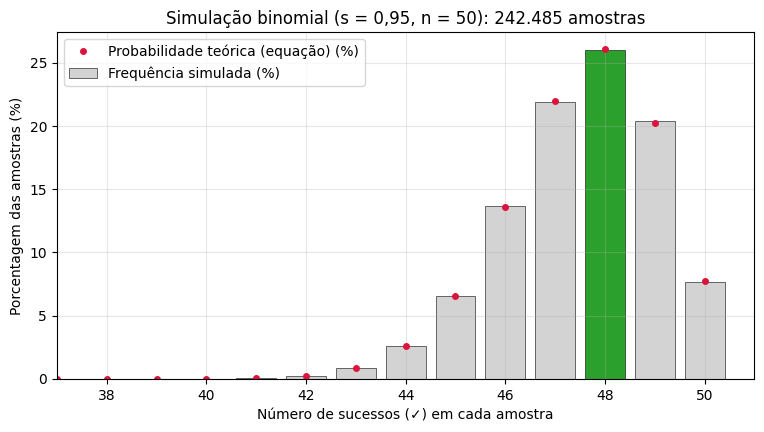

In [17]:
fig = histograma_binomial(contagens95, N_TENTATIVAS, 0.95, 48, "Simulação binomial (s = 0,95, n = 50): 242.485 amostras")
plt.show()

**Interpretação do gráfico:** cada barra é a **porcentagem das 242.485 amostras** com k sucessos; os pontos vermelhos são a probabilidade teórica pela equação. A barra verde (k = 48) é a do slide. As barras acompanham os pontos, a distribuição é **assimétrica à esquerda** (concentrada junto ao máximo possível, 50) e o valor mais frequente é 48, com ≈ 26 %.

<a id="c3"></a>
## C.3 — Cálculo explícito pela equação (validação com s = 0,95)

Calculamos P(X = 48) para n = 50 e p = 0,95 **passo a passo**, mostrando cada fator da equação, e comparamos com `scipy.stats.binom.pmf` e com a frequência simulada. Em seguida, a tabela compara equação, scipy e simulação para k de 40 a 50.

In [18]:
n, k, p = 50, 48, 0.95
combinacoes = math.comb(n, k)
termo_p = p**k
termo_q = (1 - p) ** (n - k)
print(f"C({n},{k}) = {combinacoes}")
print(f"p^k = {p}^{k} = {termo_p:.6f}")
print(f"q^(n-k) = {1-p:.2f}^{n-k} = {termo_q:.6f}")
print(f"P(X={k}) = {combinacoes} x {termo_p:.6f} x {termo_q:.6f} = {combinacoes*termo_p*termo_q:.6f} = {100*combinacoes*termo_p*termo_q:.2f} %")
print(f"scipy.stats.binom.pmf = {stats.binom.pmf(k, n, p):.6f}")
print(f"Frequência simulada de {k} sucessos = {100*np.mean(contagens95 == k):.2f} %   (slide: 26,1 %)")

ks = np.arange(40, 51)
tab95 = pd.DataFrame({
    "k": ks,
    "equação (%)": [100 * probabilidade_binomial(int(i), 50, 0.95) for i in ks],
    "scipy (%)": 100 * stats.binom.pmf(ks, 50, 0.95),
    "simulação (%)": [100 * np.mean(contagens95 == i) for i in ks],
})
tab95["|equação - simulação|"] = (tab95["equação (%)"] - tab95["simulação (%)"]).abs()
display(tab95.round(3))

C(50,48) = 1225
p^k = 0.95^48 = 0.085258
q^(n-k) = 0.05^2 = 0.002500
P(X=48) = 1225 x 0.085258 x 0.002500 = 0.261101 = 26.11 %
scipy.stats.binom.pmf = 0.261101
Frequência simulada de 48 sucessos = 26.01 %   (slide: 26,1 %)


,k,equação (%),scipy (%),simulação (%),|equação - simulação|
0,40,0.013,0.013,0.014,0.001
1,41,0.060,0.060,0.055,0.004
2,42,0.243,0.243,0.242,0.001
3,43,0.860,0.860,0.860,0.000
4,44,2.599,2.599,2.612,0.013
5,45,6.584,6.584,6.514,0.070
6,46,13.598,13.598,13.670,0.072
7,47,21.987,21.987,21.930,0.058
8,48,26.110,26.110,26.013,0.097
9,49,20.249,20.249,20.431,0.182


### Explicação do resultado (C.3)

* Fatores: C(50, 48) = 1225, p⁴⁸ ≈ 0,085258 e q² = 0,0025, o que dá **P(X = 48) ≈ 0,261101 = 26,11 %** — o mesmo **26,1 %** mostrado no slide, o que valida o nosso entendimento do experimento.
* A equação e `scipy.stats.binom.pmf` dão **valores idênticos** (a função da biblioteca implementa a mesma fórmula).
* A simulação (≈ 26,0 %) fica muito próxima do valor teórico; as diferenças da última coluna são pequenas (menos de 0,2 ponto percentual em todos os k) e representam **variação aleatória**.

<a id="c4"></a>
## C.4 — Requisito do professor: s = 0,80

**O que será feito (conforme o PDF):** (1) repetir a simulação com **s = 0,80**, com os mesmos n = 50 e 242.485 amostras; (2) fazer o **cálculo explícito pela equação**; (3) **comparar** teoria e simulação; (4) mostrar o **histograma das 10 primeiras amostras**.

### (1) Simulação com s = 0,80

In [19]:
s = 0.80
rng_c80 = np.random.default_rng(80)
sorteios80, sucessos80, contagens80 = simula_amostras(N_TENTATIVAS, s, N_AMOSTRAS, rng_c80)

print(f"Parâmetros: n = {N_TENTATIVAS}, s = {s}, amostras = {N_AMOSTRAS:,}")
print("Primeira amostra:", texto_amostra(sorteios80[0], sucessos80[0]), "->", contagens80[0], "sucessos")
print(f"Média simulada de sucessos = {contagens80.mean():.3f}  |  teórica n*s = {N_TENTATIVAS*s:.1f}")
print(f"Desvio padrão simulado     = {contagens80.std():.3f}  |  teórico sqrt(n*s*(1-s)) = {math.sqrt(N_TENTATIVAS*s*(1-s)):.3f}")

Parâmetros: n = 50, s = 0.8, amostras = 242,485
Primeira amostra: ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✗ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✗ ✓ ✓ ✓ ✓ ✓ ✗ ✓ ✓ ✓ ✓ ✓ ✗ ✗ ✓ ✗ ✗ ✓ ✓ ✗ -> 42 sucessos
Média simulada de sucessos = 39.988  |  teórica n*s = 40.0
Desvio padrão simulado     = 2.825  |  teórico sqrt(n*s*(1-s)) = 2.828


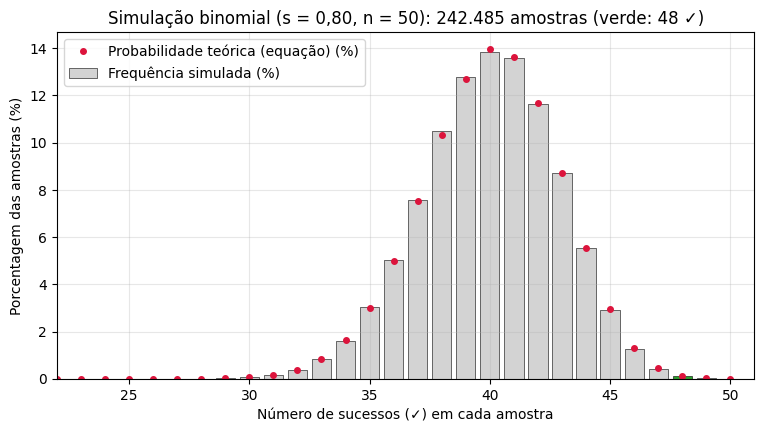

In [35]:
fig = histograma_binomial(contagens80, N_TENTATIVAS, 0.80, 48, "Simulação binomial (s = 0,80, n = 50): 242.485 amostras (verde: 48 ✓)")
plt.show()

**Interpretação do gráfico:** com s = 0,80 a distribuição fica **centrada em torno de 40 sucessos** (n·s = 50 × 0,8) e **mais larga** do que com s = 0,95 (desvio ≈ 2,83 contra ≈ 1,54). O formato é praticamente simétrico, em forma de sino. A barra verde (k = 48) agora é **minúscula** (≈ 0,1 %), ao contrário de 26 % com s = 0,95: o mesmo evento passou a ser muito raro. As barras acompanham os pontos teóricos.

### (2) e (3) Cálculo explícito pela equação e comparação

In [20]:
n, k, p = 50, 48, 0.80
combinacoes = math.comb(n, k)
print(f"C({n},{k}) = {combinacoes}")
print(f"p^k = {p}^{k} = {p**k:.6e}")
print(f"q^(n-k) = {1-p:.1f}^{n-k} = {(1-p)**(n-k):.6e}")
print(f"P(X={k}) = {combinacoes} x {p**k:.6e} x {(1-p)**(n-k):.6e} = {combinacoes*p**k*(1-p)**(n-k):.6f} = {100*probabilidade_binomial(k, n, p):.2f} %")
print(f"scipy.stats.binom.pmf = {stats.binom.pmf(k, n, p):.6f}")
print(f"Frequência simulada de {k} sucessos = {100*np.mean(contagens80 == k):.2f} %")

ks = np.arange(32, 51)
tab80 = pd.DataFrame({
    "k": ks,
    "equação (%)": [100 * probabilidade_binomial(int(i), 50, 0.80) for i in ks],
    "scipy (%)": 100 * stats.binom.pmf(ks, 50, 0.80),
    "simulação (%)": [100 * np.mean(contagens80 == i) for i in ks],
})
tab80["|equação - simulação|"] = (tab80["equação (%)"] - tab80["simulação (%)"]).abs()
display(tab80.round(3))

# Uma probabilidade acumulada: P(X >= 45), somando as probabilidades da equação
p_ge45_eq = sum(probabilidade_binomial(i, 50, 0.80) for i in range(45, 51))
print(f"\nP(X >= 45): equação = {100*p_ge45_eq:.3f} % | scipy = {100*stats.binom.sf(44, 50, 0.80):.3f} % | simulação = {100*np.mean(contagens80 >= 45):.3f} %")
print("Valor mais provável (moda) pela equação: k =", int(ks[np.argmax(tab80['equação (%)'])]))

C(50,48) = 1225
p^k = 0.8^48 = 2.230075e-05
q^(n-k) = 0.2^2 = 4.000000e-02
P(X=48) = 1225 x 2.230075e-05 x 4.000000e-02 = 0.001093 = 0.11 %
scipy.stats.binom.pmf = 0.001093
Frequência simulada de 48 sucessos = 0.11 %


,k,equação (%),scipy (%),simulação (%),|equação - simulação|
0,32,0.375,0.375,0.378,0.003
1,33,0.818,0.818,0.829,0.011
2,34,1.636,1.636,1.598,0.038
3,35,2.992,2.992,3.031,0.039
4,36,4.986,4.986,5.049,0.063
5,37,7.547,7.547,7.577,0.030
6,38,10.328,10.328,10.487,0.160
7,39,12.711,12.711,12.765,0.054
8,40,13.982,13.982,13.835,0.147
9,41,13.641,13.641,13.598,0.043



P(X >= 45): equação = 4.803 % | scipy = 4.803 % | simulação = 4.726 %
Valor mais provável (moda) pela equação: k = 40


### Explicação do resultado (C.4 — equação × simulação)

* **P(X = 48 | s = 0,80)** = 1225 × 0,8⁴⁸ × 0,2² ≈ **0,00109 (≈ 0,11 %)**; a simulação encontrou ≈ 0,11 %. A concordância é boa, mas a frequência simulada de um evento tão raro depende de poucas amostras (≈ 250 em 242.485).
* A **moda** pela equação é **k = 40** (≈ 14,0 %), igual à média n·s.
* Na probabilidade acumulada, **P(X ≥ 45) ≈ 4,80 %** pela equação e pelo scipy (idênticos) e ≈ 4,73 % pela simulação.
* Em todas as linhas, equação e scipy coincidem e a simulação difere por décimos de ponto percentual. **Teoria e simulação concordam.**

### (4) Histograma das 10 primeiras amostras

**Interpretação adotada:** como nos slides, cada **amostra** é um grupo de **10 tentativas** (cada uma ✓ ou ✗, a partir de um número entre 0 e 1). Para cada uma das **10 primeiras amostras** contamos quantos ✓ teve e empilhamos: o histograma mostra **quantas amostras** tiveram 0, 1, ..., 10 sucessos. Também mostramos o esperado pela binomial, 10 × P(X = k).

In [21]:
N10 = 10          # cada amostra do slide tem 10 tentativas
rng_10 = np.random.default_rng(2026)
sorteios10, sucessos10, contagens10 = simula_amostras(N10, 0.80, 10, rng_10)   # as 10 primeiras amostras

for i in range(10):
    print(f"Amostra {i+1:2d}: {texto_amostra(sorteios10[i], sucessos10[i])}  -> {contagens10[i]} sucessos | sorteios: {sorteios10[i].round(2)}")
print("\nContagens de sucessos das 10 amostras:", contagens10)

Amostra  1: ✓ ✓ ✓ ✓ ✓ ✓ ✗ ✓ ✓ ✓  -> 9 sucessos | sorteios: [0.18 0.64 0.47 0.37 0.35 0.79 0.91 0.18 0.65 0.3 ]
Amostra  2: ✗ ✗ ✓ ✓ ✓ ✗ ✓ ✓ ✓ ✓  -> 7 sucessos | sorteios: [0.97 0.92 0.64 0.75 0.52 0.83 0.45 0.34 0.28 0.23]
Amostra  3: ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓  -> 10 sucessos | sorteios: [0.53 0.43 0.66 0.01 0.45 0.37 0.2  0.59 0.44 0.3 ]
Amostra  4: ✓ ✗ ✓ ✓ ✓ ✗ ✓ ✓ ✗ ✓  -> 7 sucessos | sorteios: [0.21 0.87 0.8  0.61 0.35 0.95 0.56 0.43 0.9  0.32]
Amostra  5: ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓  -> 10 sucessos | sorteios: [0.7  0.31 0.26 0.7  0.23 0.49 0.58 0.19 0.73 0.55]
Amostra  6: ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓  -> 10 sucessos | sorteios: [0.62 0.37 0.42 0.49 0.47 0.68 0.58 0.42 0.   0.79]
Amostra  7: ✓ ✓ ✓ ✓ ✗ ✗ ✓ ✓ ✓ ✓  -> 8 sucessos | sorteios: [0.52 0.33 0.5  0.09 0.9  0.99 0.06 0.36 0.73 0.31]
Amostra  8: ✓ ✓ ✓ ✗ ✗ ✓ ✓ ✗ ✓ ✓  -> 7 sucessos | sorteios: [0.57 0.42 0.77 0.96 0.89 0.62 0.16 0.95 0.02 0.3 ]
Amostra  9: ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✓ ✗  -> 9 sucessos | sorteios: [0.28 0.67 0.49 0.09 0.01 0.6  0.49 0.6  0.56 0.89

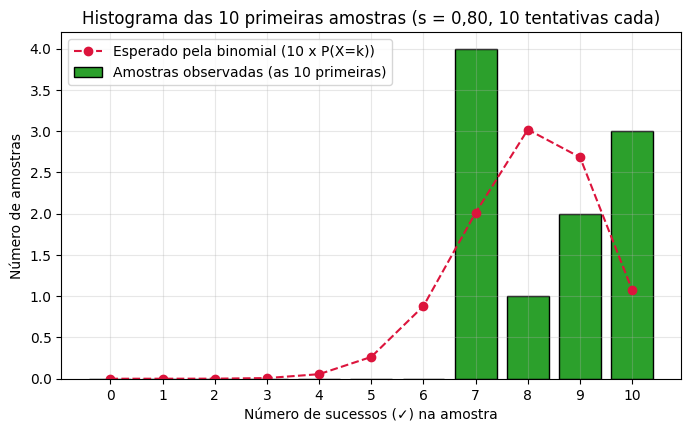

In [22]:
ks10 = np.arange(0, N10 + 1)
freq10 = np.bincount(contagens10, minlength=N10 + 1)           # nº de amostras com k sucessos
esperado10 = 10 * stats.binom.pmf(ks10, N10, 0.80)             # nº esperado de amostras entre 10

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(ks10, freq10, color="tab:green", edgecolor="black", label="Amostras observadas (as 10 primeiras)")
ax.plot(ks10, esperado10, "o--", color="crimson", label="Esperado pela binomial (10 x P(X=k))")
ax.set_xticks(ks10)
ax.set_title("Histograma das 10 primeiras amostras (s = 0,80, 10 tentativas cada)")
ax.set_xlabel("Número de sucessos (✓) na amostra")
ax.set_ylabel("Número de amostras")
ax.legend()
plt.show()

**Interpretação do gráfico:** com apenas 10 amostras, o histograma é **irregular e "pontudo"**: a contagem mais frequente foi **7 sucessos** (4 amostras), enquanto a binomial(10; 0,80) prevê o valor mais provável em **8**. Isso **não é erro** — é a variação típica de poucas observações. Dez observações **não formam uma distribuição empírica confiável**.

Para ilustrar isso, o gráfico seguinte repete o **mesmo experimento** (10 tentativas, s = 0,80) com **10.000 amostras**.

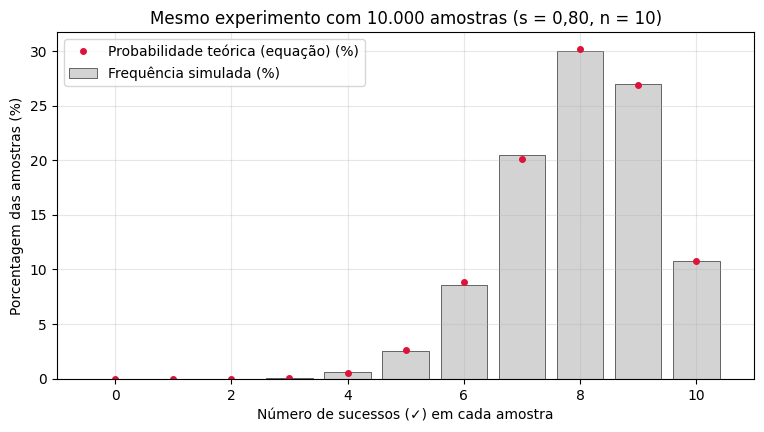

Moda observada (10 amostras): 7 | moda com 10.000 amostras: 8


In [23]:
# Para contraste: o MESMO experimento (10 tentativas, s = 0,80) com 10.000 amostras
rng_10b = np.random.default_rng(99)
_, _, contagens10_grande = simula_amostras(N10, 0.80, 10_000, rng_10b)
fig = histograma_binomial(contagens10_grande, N10, 0.80, -1, "Mesmo experimento com 10.000 amostras (s = 0,80, n = 10)")
plt.show()
print("Moda observada (10 amostras):", int(ks10[np.argmax(freq10)]), "| moda com 10.000 amostras:", int(np.bincount(contagens10_grande).argmax()))

**Interpretação do gráfico:** com 10.000 amostras, as barras acompanham de perto a curva teórica e o valor mais frequente passa a ser **8**, como a teoria prevê. Comparando com o gráfico anterior, vemos que a diferença vem do **número de repetições**, não do experimento.

<a id="c5"></a>
## C.5 — Análise detalhada e conclusão da Parte C

### Análise dos resultados

* **Teoria × simulação:** com 242.485 amostras, as frequências simuladas ficaram a décimos de ponto percentual das probabilidades da equação, tanto para s = 0,95 (26,01 % × 26,11 % para k = 48) quanto para s = 0,80 (≈ 0,105 % × 0,109 %). A equação e `scipy.stats.binom.pmf` deram valores idênticos.
* **Efeito do parâmetro s:** diminuir s de 0,95 para 0,80 **desloca** a distribuição para a esquerda (média n·s: de 47,5 para 40) e a **alarga** (desvio √(n·s·(1−s)): de ≈ 1,54 para ≈ 2,83). O evento "48 sucessos" passou de **≈ 26 %** para **≈ 0,11 %**.
* **Variação aleatória:** com poucas amostras (as 10 primeiras), o histograma ficou irregular e com a moda deslocada (7 em vez de 8); com 10.000 amostras, a forma se aproximou da teoria.
* **Frequência observada × probabilidade teórica:** a frequência é um resultado de **uma** simulação e varia entre execuções; a probabilidade é um valor fixo do modelo. Só coincidem de forma aproximada, e a aproximação melhora com mais repetições.

### Limitações

* A definição de `s` e o número exato de amostras/semente da aula **não estão no PDF**; usamos as interpretações declaradas no início da Parte C.
* Eventos raros (como k = 48 com s = 0,80) exigem muitas amostras para serem estimados com precisão.
* O modelo binomial supõe tentativas independentes e probabilidade constante.

### Conclusão

A simulação reproduziu o slide original (≈ 26 % para 48 ✓ com s = 0,95) e, para **s = 0,80**, concordou com o cálculo explícito pela equação binomial. O histograma das 10 primeiras amostras mostra a variabilidade de amostras pequenas e **não substitui** a distribuição teórica. Mais amostras aproximam as frequências simuladas das probabilidades teóricas.

<a id="parte-d"></a>
# Parte D — *Sample distribution* e *Sampling distribution*

### Figura do enunciado — Parte D

<p><b>Slide/página 31 do PDF:</b></p>
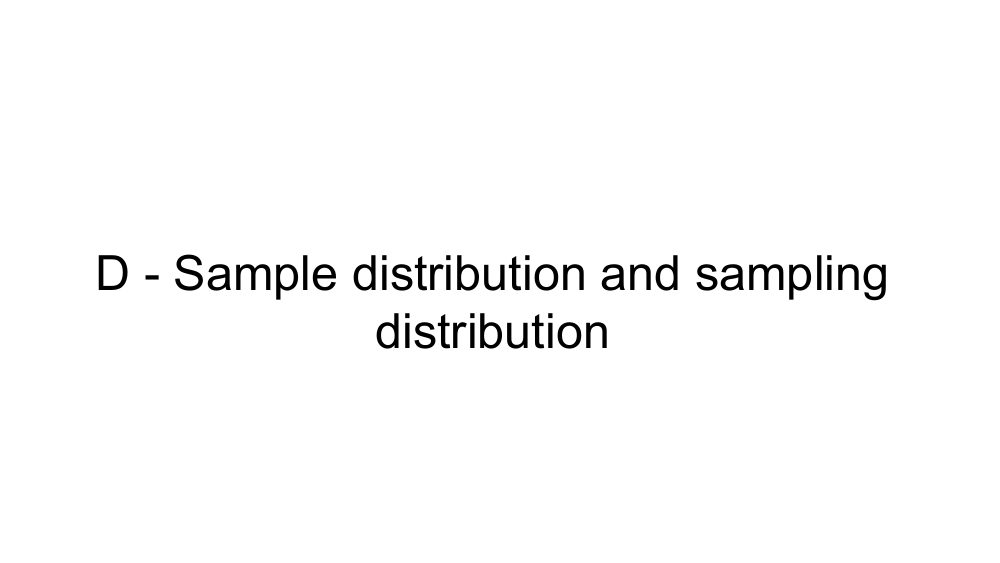

<p><b>Slide/página 32 do PDF:</b></p>
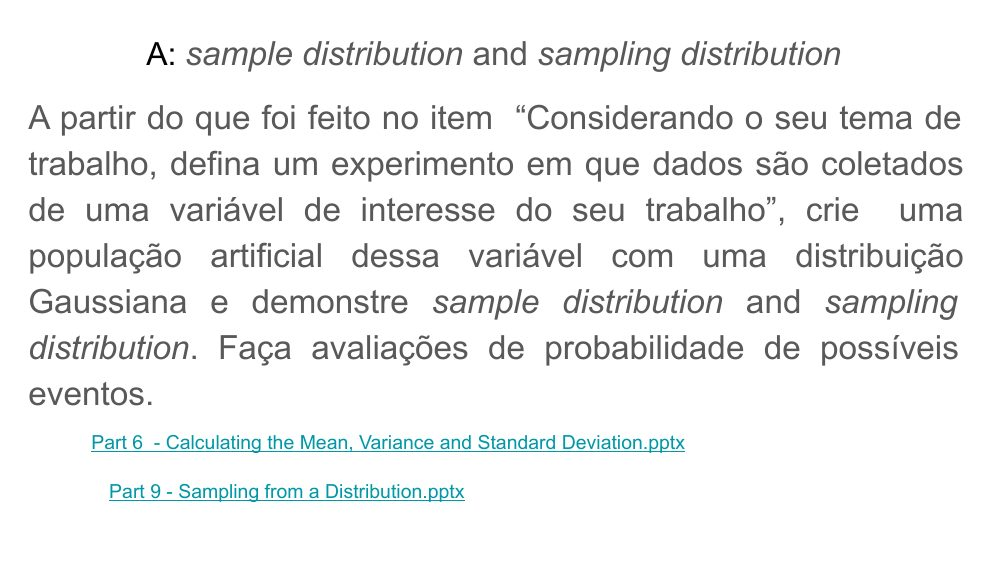



**Enunciado (resumo do PDF):** a partir do experimento definido na Parte B (variável de interesse do seu trabalho), criar uma **população artificial** dessa variável com **distribuição Gaussiana** e demonstrar *sample distribution* e *sampling distribution*; fazer **avaliações de probabilidade** de possíveis eventos.

> ⚠️ O PDF cita os slides "Part 9 – Sampling from a Distribution" e "Part 6 – Calculating the Mean, Variance and Standard Deviation", que **não estão no PDF**. Os detalhes (tamanho de amostra, nº de repetições) são, portanto, **escolhas nossas**.

**Mesmo tema da Parte B:** CTR diário (%) de campanhas de marketing digital, **dados simulados**.

<a id="d1"></a>
## D.1 — População artificial

Criamos uma **população simulada** de **100.000** valores de CTR com distribuição **Gaussiana** (μ = 2,4 %, σ = 0,5 p.p., a mesma "verdade" usada na Parte B), com semente aleatória **2024**. Não é uma população real: é um conjunto fabricado em que **conhecemos** os parâmetros, o que nos permite comparar resultados de amostras com a "verdade".

In [24]:
SEMENTE_D = 2024
rng_d = np.random.default_rng(SEMENTE_D)

MU_POP, SIGMA_POP, N_POP = 2.4, 0.5, 100_000     # população SIMULADA de CTR (%), mesmo tema da parte B
populacao = rng_d.normal(MU_POP, SIGMA_POP, N_POP)

print(f"População artificial: N = {N_POP:,}, semente = {SEMENTE_D}")
print(f"Parâmetros definidos: μ = {MU_POP}, σ = {SIGMA_POP}")
print(f"Valores observados na população gerada: média = {populacao.mean():.4f}, desvio padrão = {populacao.std():.4f}")

População artificial: N = 100,000, semente = 2024
Parâmetros definidos: μ = 2.4, σ = 0.5
Valores observados na população gerada: média = 2.4013, desvio padrão = 0.4994


### Explicação do resultado (D.1)
A média e o desvio padrão dos 100.000 valores gerados ficam muito próximos dos parâmetros (2,4 e 0,5), como esperado para uma população tão grande. Daqui em diante, **μ = 2,4 e σ = 0,5** são os parâmetros populacionais.

<a id="d2"></a>
## D.2 — Uma amostra

Retiramos **uma amostra aleatória de n = 30** campanhas da população e calculamos suas estatísticas. (Escolha experimental: n = 30.)

In [25]:
N_AMOSTRA = 30
amostra = rng_d.choice(populacao, size=N_AMOSTRA, replace=False)   # uma amostra aleatória simples

print("Dados da amostra (CTR, %):")
print(np.round(amostra, 2))
print(f"\nMédia da amostra = {amostra.mean():.4f} | desvio padrão = {amostra.std(ddof=1):.4f} | mín = {amostra.min():.2f} | máx = {amostra.max():.2f}")
print(f"Diferença entre média da amostra e média da população: {amostra.mean() - MU_POP:+.4f}")

Dados da amostra (CTR, %):
[1.48 2.95 2.87 3.39 2.76 2.67 2.67 2.08 2.3  1.66 2.17 2.23 2.03 2.46
 2.32 1.39 2.42 2.99 2.48 2.1  1.48 2.61 2.52 2.73 2.07 2.62 2.27 2.27
 2.22 2.14]

Média da amostra = 2.3453 | desvio padrão = 0.4626 | mín = 1.39 | máx = 3.39
Diferença entre média da amostra e média da população: -0.0547


### Explicação do resultado (D.2)
A amostra tem 30 valores; sua média e seu desvio padrão são **estimativas** de μ e σ e **não são idênticos** a eles. Uma amostra diferente teria média diferente — é essa variação que a *sampling distribution* vai descrever.

<a id="d3"></a>
## D.3 — Sample distribution

A ***sample distribution*** é a distribuição dos **valores individuais dentro de uma única amostra**: cada observação é um CTR. Fazemos o histograma dos 30 valores da amostra.

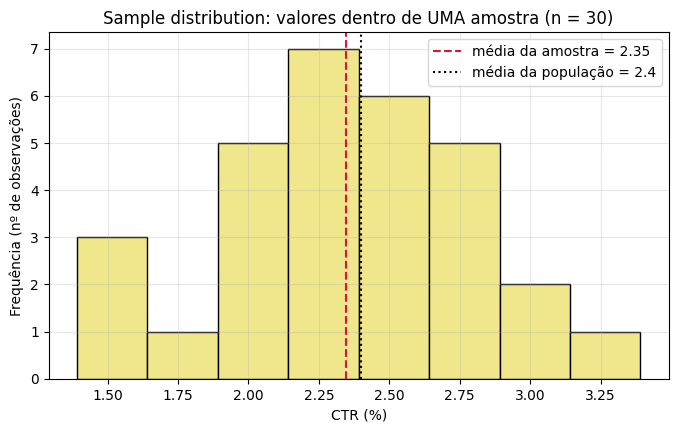

In [26]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(amostra, bins=8, color="khaki", edgecolor="black")
ax.axvline(amostra.mean(), color="crimson", linestyle="--", label=f"média da amostra = {amostra.mean():.2f}")
ax.axvline(MU_POP, color="black", linestyle=":", label=f"média da população = {MU_POP}")
ax.set_title(f"Sample distribution: valores dentro de UMA amostra (n = {N_AMOSTRA})")
ax.set_xlabel("CTR (%)")
ax.set_ylabel("Frequência (nº de observações)")
ax.legend()
plt.show()

**Interpretação do gráfico:** cada barra conta quantas das **30 campanhas daquela amostra** caíram em cada faixa de CTR. Com só 30 valores, o histograma é **irregular** (não é uma curva suave) e a média da amostra (linha vermelha) pode ficar um pouco longe da média da população (linha preta). Isso é natural em amostras pequenas.

<a id="d4"></a>
## D.4 — Sampling distribution

A ***sampling distribution*** de uma estatística é a distribuição dos valores dessa **estatística** calculada em **muitas amostras** da mesma população. Aqui, a estatística é a **média**. Retiramos **5.000 amostras de tamanho 30** e calculamos a média de cada uma. (Sorteio com reposição; como a população tem 100.000 valores e cada amostra apenas 30, a diferença para sorteio sem reposição é desprezível.)

O **erro padrão** teórico da média é $\sigma/\sqrt{n}$. O gráfico empilha as três distribuições (mesmo eixo x) para destacar as diferenças.

Nº de amostras = 5,000 | tamanho de cada amostra n = 30
Média das médias amostrais  = 2.4033  (média populacional μ = 2.4)
Desvio padrão das médias    = 0.0910  (erro padrão teórico σ/√n = 0.0913)


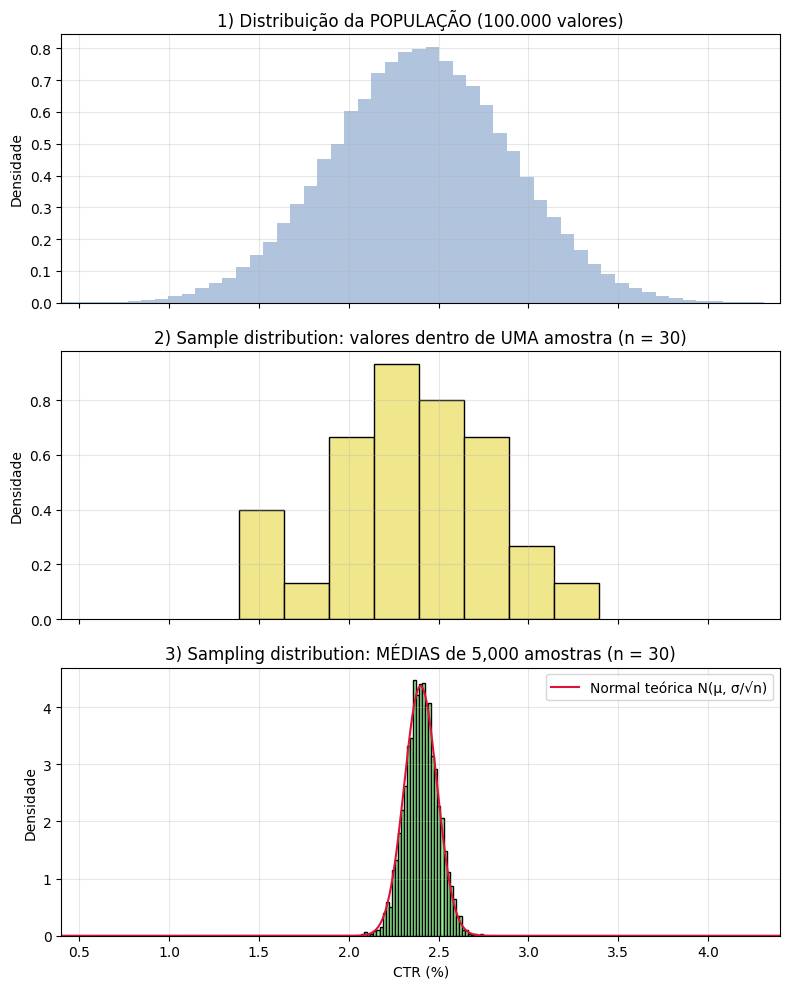

In [27]:
N_REPETICOES = 5_000
matriz = rng_d.choice(populacao, size=(N_REPETICOES, N_AMOSTRA), replace=True)  # 5.000 amostras de tamanho 30
medias_amostrais = matriz.mean(axis=1)                                         # uma média por amostra

erro_padrao_teorico = SIGMA_POP / math.sqrt(N_AMOSTRA)
print(f"Nº de amostras = {N_REPETICOES:,} | tamanho de cada amostra n = {N_AMOSTRA}")
print(f"Média das médias amostrais  = {medias_amostrais.mean():.4f}  (média populacional μ = {MU_POP})")
print(f"Desvio padrão das médias    = {medias_amostrais.std(ddof=1):.4f}  (erro padrão teórico σ/√n = {erro_padrao_teorico:.4f})")

lim = (MU_POP - 4 * SIGMA_POP, MU_POP + 4 * SIGMA_POP)
fig, eixos = plt.subplots(3, 1, figsize=(8, 10), sharex=True)
eixos[0].hist(populacao, bins=60, density=True, color="lightsteelblue", edgecolor="none")
eixos[0].set_title("1) Distribuição da POPULAÇÃO (100.000 valores)")
eixos[1].hist(amostra, bins=8, density=True, color="khaki", edgecolor="black")
eixos[1].set_title(f"2) Sample distribution: valores dentro de UMA amostra (n = {N_AMOSTRA})")
eixos[2].hist(medias_amostrais, bins=40, density=True, color="lightgreen", edgecolor="black")
xx = np.linspace(*lim, 400)
eixos[2].plot(xx, stats.norm.pdf(xx, MU_POP, erro_padrao_teorico), color="crimson", label="Normal teórica N(μ, σ/√n)")
eixos[2].set_title(f"3) Sampling distribution: MÉDIAS de {N_REPETICOES:,} amostras (n = {N_AMOSTRA})")
eixos[2].legend()
for ax in eixos:
    ax.set_ylabel("Densidade")
eixos[2].set_xlabel("CTR (%)")
eixos[2].set_xlim(*lim)
plt.tight_layout(); plt.show()

**Interpretação do gráfico — as três distribuições:**
1. **População (painel 1):** os 100.000 valores individuais; larga (σ = 0,5).
2. ***Sample distribution* (painel 2):** os 30 valores de **uma** amostra; irregular e com dispersão parecida com a da população.
3. ***Sampling distribution* das médias (painel 3):** os 5.000 valores de **médias**; **muito mais estreita**, centrada em μ = 2,4 e acompanhando a normal teórica N(μ, σ/√n).

Os números impressos confirmam: **média das médias ≈ 2,403** (≈ μ) e **desvio padrão das médias ≈ 0,091**, quase igual ao erro padrão teórico **0,0913**.

<a id="d5"></a>
## D.5 — Avaliações de probabilidade

Avaliamos três eventos, cada um **estimado por simulação** (fração dos casos em que o evento ocorre) e **calculado teoricamente** com a normal:

| Evento | Estatística analisada | Modelo teórico |
|---|---|---|
| 1) CTR individual > 3,0 % | uma observação | N(μ, σ) |
| 2) média amostral > 2,6 % | média de n = 30 | N(μ, σ/√n) |
| 3) 2,3 % < média amostral < 2,5 % | média de n = 30 | N(μ, σ/√n) |

Para as médias usamos o **erro padrão σ/√n** no lugar de σ.

In [28]:
def tabela_evento(nome, estatistica, simulado, teorico):
    return {"evento": nome, "estatística": estatistica, "simulação": simulado, "teórica": teorico,
            "|diferença|": abs(simulado - teorico)}

ep = erro_padrao_teorico
eventos = [
    # Evento 1: um único valor (observação individual) da população
    tabela_evento("P(CTR individual > 3,0)", "observação individual",
                  np.mean(populacao > 3.0), stats.norm.sf(3.0, MU_POP, SIGMA_POP)),
    # Evento 2: média de uma amostra de n = 30
    tabela_evento("P(média amostral > 2,6)", f"média de n={N_AMOSTRA}",
                  np.mean(medias_amostrais > 2.6), stats.norm.sf(2.6, MU_POP, ep)),
    # Evento 3: média dentro de um intervalo
    tabela_evento("P(2,3 < média amostral < 2,5)", f"média de n={N_AMOSTRA}",
                  np.mean((medias_amostrais > 2.3) & (medias_amostrais < 2.5)),
                  stats.norm.cdf(2.5, MU_POP, ep) - stats.norm.cdf(2.3, MU_POP, ep)),
]
display(pd.DataFrame(eventos).round(4))

# Cálculo passo a passo do evento 2 (padronizando a média amostral)
z2 = (2.6 - MU_POP) / ep
print(f"Evento 2: z = (2,6 - {MU_POP}) / ({SIGMA_POP}/√{N_AMOSTRA}) = {z2:.3f}  ->  P(Z > z) = {stats.norm.sf(z2):.4f}")

,evento,estatística,simulação,teórica,|diferença|
0,"P(CTR individual > 3,0)",observação individual,0.1158,0.1151,0.0008
1,"P(média amostral > 2,6)",média de n=30,0.0148,0.0142,0.0006
2,"P(2,3 < média amostral < 2,5)",média de n=30,0.7296,0.7267,0.0029


Evento 2: z = (2,6 - 2.4) / (0.5/√30) = 2.191  ->  P(Z > z) = 0.0142


### Explicação do resultado (D.5)

* **Evento 1:** ≈ **11,5 %** das campanhas individuais têm CTR acima de 3,0 % (simulado ≈ 11,6 %).
* **Evento 2:** a probabilidade de a **média** de 30 campanhas passar de 2,6 % é só ≈ **1,4 %** (teórica 1,42 %; z ≈ 2,19). Ou seja, **a média raramente se afasta muito de μ**, mesmo que valores individuais se afastem com frequência.
* **Evento 3:** ≈ **72,7 %** de chance de a média de 30 campanhas ficar entre 2,3 % e 2,5 %.
* Para os três eventos, **simulação e teoria diferem em menos de 0,3 ponto percentual**. Note a diferença de interpretação: o mesmo limite (valores acima de ≈ 2,6–3,0) é comum para observações individuais, mas **raro** para médias.

Para estudar o **efeito do tamanho da amostra**, repetimos a *sampling distribution* com n = 5, 30, 100 e 500 (mesmo eixo x, 5.000 amostras cada).

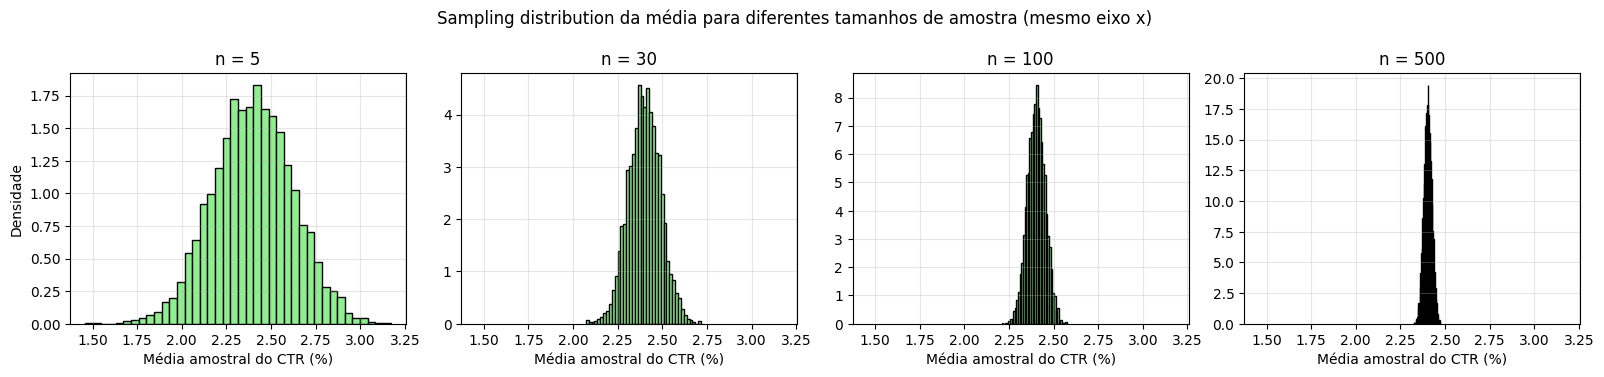

,n,desvio padrão das médias (simulado),erro padrão teórico σ/√n,"P(média > 2,6) simulada","P(média > 2,6) teórica"
0,5,0.2237,0.2236,0.181,0.1855
1,30,0.0897,0.0913,0.012,0.0142
2,100,0.0495,0.0500,0.000,0.0000
3,500,0.0223,0.0224,0.000,0.0000


In [29]:
tamanhos = [5, 30, 100, 500]
linhas = []
fig, eixos = plt.subplots(1, 4, figsize=(16, 3.8), sharex=True)
for ax, n_i in zip(eixos, tamanhos):
    medias_i = rng_d.choice(populacao, size=(N_REPETICOES, n_i), replace=True).mean(axis=1)
    ax.hist(medias_i, bins=40, density=True, color="lightgreen", edgecolor="black")
    ax.set_title(f"n = {n_i}")
    ax.set_xlabel("Média amostral do CTR (%)")
    linhas.append({"n": n_i, "desvio padrão das médias (simulado)": medias_i.std(ddof=1),
                   "erro padrão teórico σ/√n": SIGMA_POP / math.sqrt(n_i),
                   "P(média > 2,6) simulada": np.mean(medias_i > 2.6),
                   "P(média > 2,6) teórica": stats.norm.sf(2.6, MU_POP, SIGMA_POP / math.sqrt(n_i))})
eixos[0].set_ylabel("Densidade")
fig.suptitle("Sampling distribution da média para diferentes tamanhos de amostra (mesmo eixo x)")
plt.tight_layout(); plt.show()
display(pd.DataFrame(linhas).round(4))

**Interpretação do gráfico:** conforme **n aumenta**, a distribuição das médias fica **mais estreita**, mantendo-se centrada em ≈ 2,4. A tabela mostra que o desvio padrão simulado das médias acompanha o erro padrão teórico σ/√n (0,224 → 0,091 → 0,050 → 0,022), e que a probabilidade de a média passar de 2,6 % **cai** de ≈ 18 % (n = 5) para ≈ 1 % (n = 30) e praticamente zero para n ≥ 100.

<a id="d6"></a>
## D.6 — Análise detalhada e conclusão da Parte D

### Análise dos resultados

* **Três distribuições diferentes:** a **população** descreve todos os valores; a ***sample distribution*** descreve os valores dentro de **uma** amostra (histograma irregular de 30 valores); a ***sampling distribution*** descreve a **média** calculada em muitas amostras e é bem mais estreita.
* **Variabilidade entre amostras:** a média de uma amostra de 30 (≈ 2,35) não é exatamente μ = 2,4, e outras amostras dariam outros valores. A sampling distribution mostra o tamanho típico dessa oscilação: o erro padrão ≈ 0,09.
* **Relação com a média populacional:** a média das 5.000 médias (≈ 2,403) ficou praticamente igual a μ — a média amostral é um estimador **não viesado** da média populacional.
* **Efeito de n:** o erro padrão diminui com √n; quadruplicar n reduz o erro padrão pela metade (de n = 5 para n = 30, de 0,224 para 0,091; de 30 para 100, para 0,050).
* **Probabilidades:** o mesmo limite pode ser comum para valores individuais (11,5 % acima de 3,0) e raro para médias (1,4 % acima de 2,6 com n = 30). Simulação e teoria concordaram em todos os eventos.

### Limitações
* A população é **simulada e gaussiana por construção**, então a sampling distribution da média ser normal é esperado (para populações gaussianas isso vale para qualquer n; o TLC, na Parte E, trata do caso não gaussiano).
* Os cálculos teóricos usaram os **parâmetros nominais** (μ = 2,4; σ = 0,5); em um problema real, esses parâmetros seriam desconhecidos.
* A simulação usou 5.000 amostras: eventos muito raros teriam estimativas imprecisas.

### Conclusão
Criamos uma população gaussiana artificial de CTR, mostramos a diferença entre sample distribution e sampling distribution e verificamos que a distribuição das médias é centrada em μ com dispersão σ/√n, que diminui com o tamanho da amostra. As probabilidades de eventos estimadas por simulação coincidiram com as teóricas.

<a id="parte-e"></a>
# Parte E — Teorema do Limite Central (TLC) com a distribuição Gamma

### Figura do enunciado — Parte E

<p><b>Slide/página 33 do PDF:</b></p>
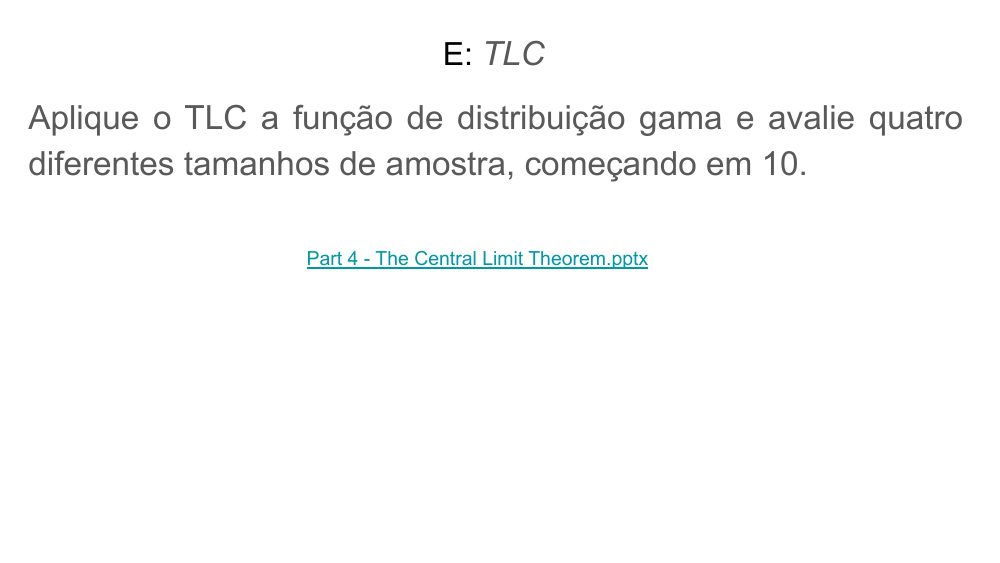



**Enunciado (resumo do PDF):** *"Aplique o TLC à função de distribuição gama e avalie quatro diferentes tamanhos de amostra, começando em 10."*

> ⚠️ O PDF cita o slide "Part 4 – The Central Limit Theorem", que **não está no PDF**. Os parâmetros da Gamma, os outros três tamanhos de amostra e o nº de repetições **não foram especificados** e são **escolhas experimentais nossas**.

**Teorema (ideia):** se tomamos amostras independentes de tamanho *n* de uma distribuição com média μ e desvio σ finitos, a distribuição da **média amostral** se aproxima de uma **normal** com média μ e desvio σ/√n quando *n* cresce — **mesmo que a distribuição original não seja normal**.

<a id="e1"></a>
## E.1 — Definição da distribuição Gamma

A distribuição **Gamma** é definida para valores positivos e é **assimétrica à direita** (cauda longa para a direita). É usada, por exemplo, para tempos de espera e valores positivos assimétricos.

**Parametrização usada (declarada explicitamente):** **forma *k*** e **escala *θ***. No `scipy.stats.gamma`, `a = k` e `scale = θ`; no `numpy`, `rng.gamma(shape=k, scale=θ)`. (A parametrização por **taxa** *β* usa β = 1/θ.)

* **Escolha experimental:** **k = 2** e **θ = 2** (taxa = 0,5), valores positivos que dão uma distribuição claramente assimétrica, boa para testar o TLC.
* **Média** = k·θ = 4; **variância** = k·θ² = 8 (desvio ≈ 2,83); **assimetria** = 2/√k ≈ 1,41.
* **Geração dos dados:** `rng.gamma` com semente fixa (`default_rng(321)`).

Gamma(k = 2.0, θ = 2.0)  [taxa = 0.5]
Média teórica  = k·θ   = 4.000
Variância      = k·θ²  = 8.000  ->  desvio padrão = 2.828
Assimetria     = 2/√k  = 1.414  (distribuição assimétrica à direita)


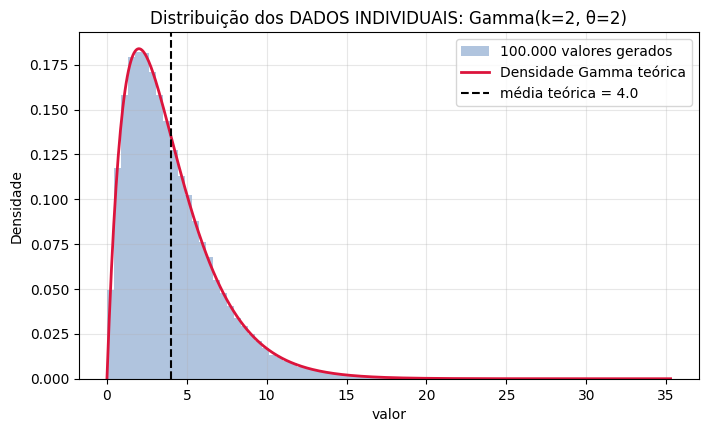

In [30]:
FORMA_K = 2.0      # parâmetro de forma (k ou "a" no scipy)
ESCALA_THETA = 2.0 # parâmetro de escala (θ);  taxa = 1/θ = 0,5

gama = stats.gamma(a=FORMA_K, scale=ESCALA_THETA)   # scipy: gamma(a=forma, scale=escala)
mu_g, var_g = gama.mean(), gama.var()
sigma_g = math.sqrt(var_g)
assim_g = 2 / math.sqrt(FORMA_K)                      # assimetria teórica da Gamma

print(f"Gamma(k = {FORMA_K}, θ = {ESCALA_THETA})  [taxa = {1/ESCALA_THETA}]")
print(f"Média teórica  = k·θ   = {mu_g:.3f}")
print(f"Variância      = k·θ²  = {var_g:.3f}  ->  desvio padrão = {sigma_g:.3f}")
print(f"Assimetria     = 2/√k  = {assim_g:.3f}  (distribuição assimétrica à direita)")

rng_e = np.random.default_rng(321)
pop_gama = rng_e.gamma(shape=FORMA_K, scale=ESCALA_THETA, size=100_000)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(pop_gama, bins=80, density=True, color="lightsteelblue", edgecolor="none", label="100.000 valores gerados")
xx = np.linspace(0, pop_gama.max(), 500)
ax.plot(xx, gama.pdf(xx), color="crimson", linewidth=2, label="Densidade Gamma teórica")
ax.axvline(mu_g, color="black", linestyle="--", label=f"média teórica = {mu_g:.1f}")
ax.set_title("Distribuição dos DADOS INDIVIDUAIS: Gamma(k=2, θ=2)")
ax.set_xlabel("valor"); ax.set_ylabel("Densidade"); ax.legend()
plt.show()

**Interpretação do gráfico:** esta é a distribuição dos **dados individuais**. Ela **não é simétrica**: concentra-se em valores baixos (pico perto de 2), tem cauda longa à direita e nenhum valor negativo. As barras seguem a densidade teórica. A média teórica (4) fica à **direita** do pico. Esta é a forma que o TLC **não** altera: os dados individuais continuam Gamma.

<a id="e2"></a>
## E.2 — Quatro tamanhos de amostra

**Tamanhos:** **n = 10** (exigido pelo professor) e **30, 50 e 100** (três escolhas experimentais nossas). Para **cada n**:
1. geramos **10.000 amostras independentes** de tamanho n da Gamma(2, 2);
2. calculamos a **média de cada amostra**;
3. comparamos com a média teórica (4), o erro padrão teórico σ/√n, a assimetria teórica das médias 2/√(k·n) e a distância (estatística KS) entre as médias padronizadas e a normal padrão — quanto **menor**, mais parecida com a normal.

Os histogramas vêm nas próximas células.

In [31]:
TAMANHOS = [10, 30, 50, 100]    # n = 10 pedido pelo professor; os outros três são escolhas experimentais
N_REP = 10_000                   # nº de amostras independentes para cada n

medias_por_n = {}
for n_i in TAMANHOS:
    amostras = rng_e.gamma(shape=FORMA_K, scale=ESCALA_THETA, size=(N_REP, n_i))
    medias_por_n[n_i] = amostras.mean(axis=1)

linhas = []
for n_i, med in medias_por_n.items():
    z = (med - mu_g) / (sigma_g / math.sqrt(n_i))     # médias padronizadas
    linhas.append({
        "n": n_i,
        "média das médias": med.mean(), "média teórica kθ": mu_g,
        "desvio padrão das médias": med.std(ddof=1), "erro padrão teórico σ/√n": sigma_g / math.sqrt(n_i),
        "assimetria simulada": stats.skew(med), "assimetria teórica 2/√(k·n)": assim_g / math.sqrt(n_i),
        "distância KS à normal": stats.kstest(z, "norm").statistic,
    })
tabela_tlc = pd.DataFrame(linhas).set_index("n")
display(tabela_tlc.round(4))

,média das médias,média teórica kθ,desvio padrão das médias,erro padrão teórico σ/√n,assimetria simulada,assimetria teórica 2/√(k·n),distância KS à normal
n,,,,,,,
10,4.0042,4.0,0.8982,0.8944,0.4629,0.4472,0.0326
30,4.0027,4.0,0.5203,0.5164,0.2826,0.2582,0.0172
50,3.9968,4.0,0.4012,0.4000,0.1890,0.2000,0.0173
100,3.9988,4.0,0.2792,0.2828,0.1574,0.1414,0.0176


### Explicação do resultado (E.2)

* **Média das médias:** ≈ 4,00 para todos os n, praticamente igual à média teórica **4**: a média amostral é centrada na média populacional.
* **Dispersão:** o desvio padrão das médias cai conforme σ/√n (≈ 0,90; 0,52; 0,40; 0,28), coincidindo com o erro padrão teórico (0,894; 0,516; 0,400; 0,283).
* **Forma:** a assimetria das médias cai de ≈ 0,46 (n = 10) para ≈ 0,16 (n = 100), bem abaixo da assimetria dos dados individuais (≈ 1,41), em linha com a fórmula 2/√(k·n). A distância KS cai de ≈ 0,033 (n = 10) para ≈ 0,017 em n = 30 e **depois fica aproximadamente estável** (≈ 0,017–0,018): com 10.000 repetições, esse valor já está próximo do nível de ruído da própria simulação, então diferenças entre n = 30, 50 e 100 **não** são distinguíveis por essa medida.

<a id="e3"></a>
## E.3 — Comparação visual

**Figura 1 — médias amostrais na escala original (mesmo eixo x):** mostra o **encolhimento da dispersão**. Em vermelho, a normal com média μ e desvio σ/√n.

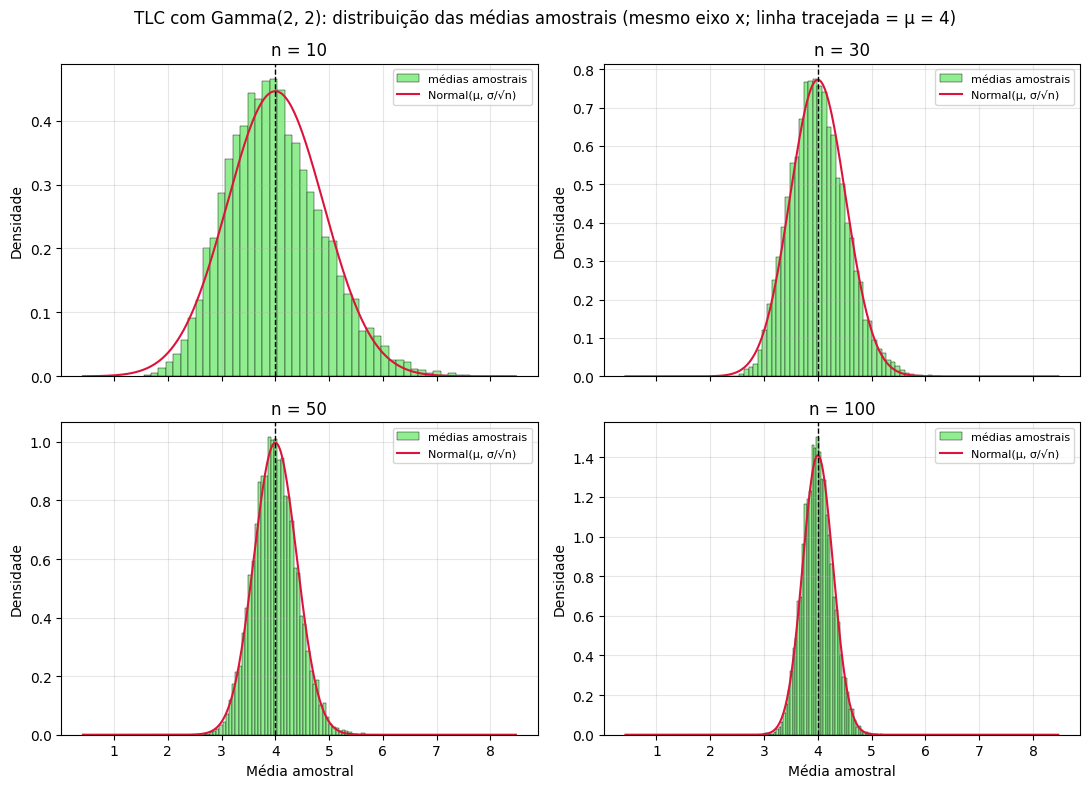

In [32]:
fig, eixos = plt.subplots(2, 2, figsize=(11, 8), sharex=True)
for ax, n_i in zip(eixos.ravel(), TAMANHOS):
    med = medias_por_n[n_i]
    ep_i = sigma_g / math.sqrt(n_i)
    ax.hist(med, bins=50, density=True, color="lightgreen", edgecolor="black", linewidth=0.3, label="médias amostrais")
    xx = np.linspace(mu_g - 4 * sigma_g / math.sqrt(10), mu_g + 5 * sigma_g / math.sqrt(10), 500)
    ax.plot(xx, stats.norm.pdf(xx, mu_g, ep_i), color="crimson", label="Normal(μ, σ/√n)")
    ax.axvline(mu_g, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"n = {n_i}")
    ax.set_ylabel("Densidade")
    ax.legend(fontsize=8)
for ax in eixos[1]:
    ax.set_xlabel("Média amostral")
fig.suptitle("TLC com Gamma(2, 2): distribuição das médias amostrais (mesmo eixo x; linha tracejada = μ = 4)")
plt.tight_layout(); plt.show()

**Interpretação do gráfico (Figura 1):** com **n = 10** a distribuição das médias é larga e ainda tem **leve cauda à direita**; com **n = 30, 50 e 100** ela fica **cada vez mais estreita** em torno de 4 e mais simétrica. A curva normal vermelha acompanha as barras em todos os painéis, melhor nos maiores n. Como o eixo x é o mesmo, a redução da largura é visível: isto é a **redução da dispersão (σ/√n)**.

**Figura 2 — médias padronizadas:** cada média é transformada em z = (média − μ) / (σ/√n). Isso **remove** o efeito da dispersão e deixa apenas a **forma**, que comparamos com a normal padrão.

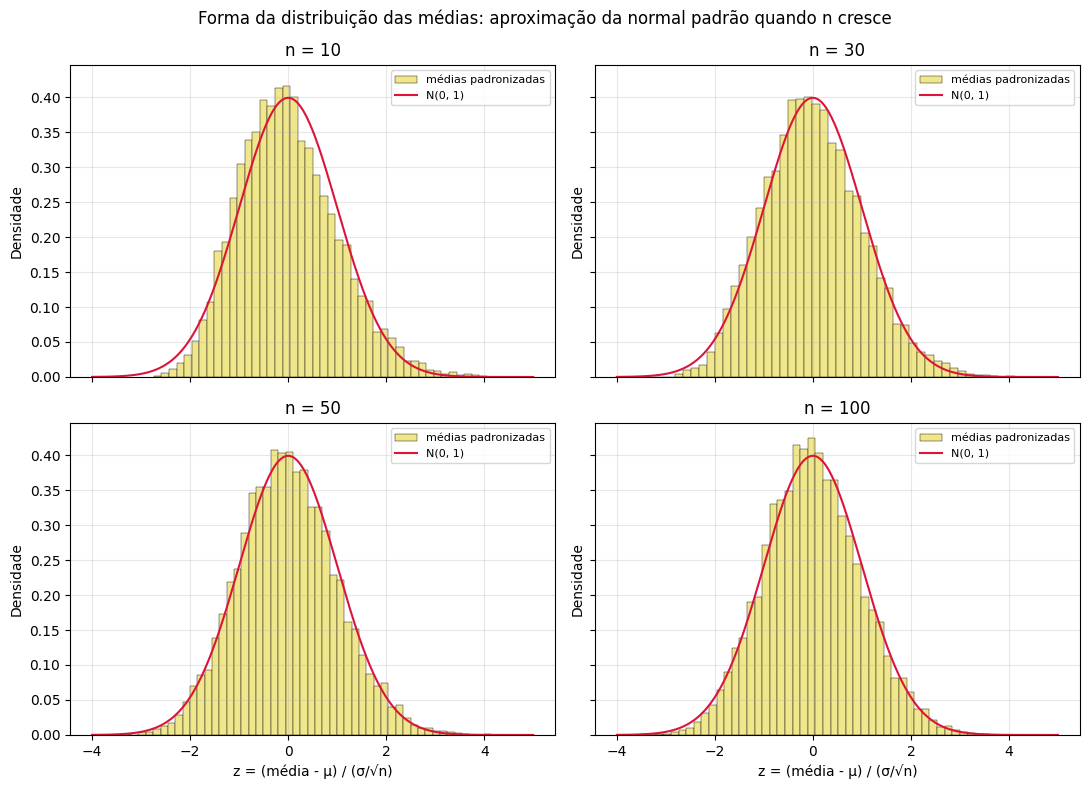

In [33]:
fig, eixos = plt.subplots(2, 2, figsize=(11, 8), sharex=True, sharey=True)
zz = np.linspace(-4, 5, 500)
for ax, n_i in zip(eixos.ravel(), TAMANHOS):
    z = (medias_por_n[n_i] - mu_g) / (sigma_g / math.sqrt(n_i))
    ax.hist(z, bins=50, density=True, color="khaki", edgecolor="black", linewidth=0.3, label="médias padronizadas")
    ax.plot(zz, stats.norm.pdf(zz), color="crimson", label="N(0, 1)")
    ax.set_title(f"n = {n_i}")
    ax.set_ylabel("Densidade")
    ax.legend(fontsize=8)
for ax in eixos[1]:
    ax.set_xlabel("z = (média - μ) / (σ/√n)")
fig.suptitle("Forma da distribuição das médias: aproximação da normal padrão quando n cresce")
plt.tight_layout(); plt.show()

**Interpretação do gráfico (Figura 2):** com a dispersão neutralizada, todos os painéis têm a mesma escala. Em **n = 10** o histograma ainda é um pouco assimétrico (pico deslocado e cauda direita mais longa que a normal); em **n ≥ 30** ele se aproxima bastante da curva N(0, 1). Assim separamos dois efeitos: **a forma** que vai se aproximando da normal (Figura 2) e **a dispersão** que diminui (Figura 1).

**Fórmulas:** média das médias = μ = k·θ; erro padrão = σ/√n, com σ = √(k·θ²).

<a id="e4"></a>
## E.4 — Análise detalhada e conclusão da Parte E

### Análise dos resultados

* **Média:** para os quatro tamanhos (10, 30, 50, 100), a média das médias amostrais ficou em ≈ 4,00, igual à média teórica da Gamma (k·θ = 4).
* **Dispersão:** o desvio padrão das médias diminuiu como σ/√n, de ≈ 0,90 (n = 10) para ≈ 0,28 (n = 100).
* **Forma:** a assimetria das médias diminuiu com n (≈ 0,46 → ≈ 0,16) e a distribuição se aproximou da normal; a maior melhora ocorreu de n = 10 para n = 30. Para n ≥ 30, as diferenças restantes são pequenas em relação ao ruído da simulação.
* **Dois efeitos distintos:** (i) **aproximação da forma normal** e (ii) **redução da dispersão**. A Figura 1 evidencia o segundo; a Figura 2 isola o primeiro.

### O que o TLC afirma (e o que não afirma)
O TLC trata da distribuição das **médias amostrais**. Ele **não** diz que os dados individuais da população Gamma se tornam normais: a distribuição individual continua assimétrica (assimetria ≈ 1,41), como mostra o histograma da seção E.1. O que se aproxima da normal é a distribuição da **média** quando n cresce.

### Limitações
* Parâmetros (k = 2, θ = 2), tamanhos adicionais (30, 50, 100) e nº de repetições (10.000) foram escolhas nossas, pois o PDF não os especifica.
* O TLC é um resultado **assintótico**: ele descreve o limite quando n → ∞; a rapidez da aproximação depende da assimetria da distribuição original (para uma Gamma com k menor, mais assimétrica, seria preciso n maior).
* A simulação tem variação aleatória; diferenças muito pequenas entre n = 30, 50 e 100 não são conclusivas.

### Conclusão
Aplicando o TLC à Gamma(2, 2) com n = 10, 30, 50 e 100, observamos que a distribuição das médias é centrada na média teórica, tem dispersão σ/√n e se aproxima da normal à medida que n cresce — já bem próxima da normal a partir de n ≈ 30 — embora os dados individuais continuem seguindo a Gamma assimétrica.